# Analyse de l'Impact du DPE sur la Consommation Électrique Résidentielle
## Département 13 — Bouches-du-Rhône

**Sources :**  
- **Enedis** — Consommation annuelle résidentielle par adresse (2018–2024)  
- **ADEME** — Base nationale des Diagnostics de Performance Énergétique  
- **BAN** — Lieux-dits Dept. 13 (Base Adresse Nationale)

**Objectifs :**
1. Quantifier l'impact d'une amélioration de classe DPE sur la consommation réelle
2. Comparer les estimations DPE aux consommations Enedis mesurées
3. Analyser la variabilité comportementale intra-classe
4. Construire des modèles prédictifs interprétables

---

## 0. Imports & Configuration

In [6]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
import re, unicodedata, os, json

# ──────────────────────────────────────────────
# ▶▶▶  ADAPTER CES CHEMINS SI NÉCESSAIRE
DPE_PATH   = "data/dpe-france.csv"
CONSO_PATH = "data/consommation-annuelle-residentielle-par-adresse.csv"
LIEUX_PATH = "data/lieux-dits-13-beta.csv"
OUTDIR     = "outputs/figures"
# ──────────────────────────────────────────────

SEED      = 42
PRIX_KWH  = 0.2516   # tarif réglementé 2024 (€/kWh TTC)
ANNEE_REF = 2022     # année de référence Enedis
np.random.seed(SEED)

os.makedirs(OUTDIR, exist_ok=True)

CLASSES_DPE = ["A", "B", "C", "D", "E", "F", "G"]
PALETTE_DPE = {
    "A": "#00B050", "B": "#92D050", "C": "#FFFF00",
    "D": "#FFC000", "E": "#FF6600", "F": "#FF0000", "G": "#C00000",
}

plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})

print("✅ Librairies chargées | Dossiers prêts")
print(f"   DPE_PATH   : {os.path.abspath(DPE_PATH)}")
print(f"   CONSO_PATH : {os.path.abspath(CONSO_PATH)}")


✅ Librairies chargées | Dossiers prêts
   DPE_PATH   : c:\Users\ROMUALD DJAHOUA\OneDrive\Bureau\ENSAR\Open Data 13\data\dpe-france.csv
   CONSO_PATH : c:\Users\ROMUALD DJAHOUA\OneDrive\Bureau\ENSAR\Open Data 13\data\consommation-annuelle-residentielle-par-adresse.csv


## 1. Utilitaires

In [3]:
def normalize_str(s):
    """Normalise une chaîne pour jointure d'adresses (majuscules, sans accents, sans ponctuation)."""
    if pd.isna(s) or str(s).strip() == "":
        return ""
    s = str(s).upper().strip()
    s = unicodedata.normalize("NFD", s)
    s = "".join(c for c in s if unicodedata.category(c) != "Mn")
    s = re.sub(r"[^A-Z0-9 ]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def normalize_code_insee(s):
    """Normalise un code INSEE sur 5 caractères."""
    if pd.isna(s):
        return ""
    return str(s).strip().zfill(5)

print("✅ Fonctions utilitaires définies")


✅ Fonctions utilitaires définies


## 2. Chargement & Compréhension des Données

### 2.1 Données Enedis

**Granularité :** adresse postale agrégée sur ≥ 10 logements  
**Variable cible :** `consommation_annuelle_moyenne_par_site_de_ladresse_mwh`  
> ⚠️ Uniquement les adresses ≥ 10 logements → biais vers l'habitat collectif


In [4]:
conso_raw = pd.read_csv(CONSO_PATH, low_memory=False)

print(f"Lignes : {len(conso_raw):,}  |  Colonnes : {conso_raw.shape[1]}")
print(f"Années : {sorted(conso_raw['Année'].unique())}")
print(f"Communes : {conso_raw['Nom Commune'].nunique()}")
print(f"\nValeurs manquantes (colonnes > 0) :")
miss = conso_raw.isnull().sum()
print(miss[miss > 0].to_string())

conso_raw.head(3)


Lignes : 80,680  |  Colonnes : 19
Années : [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Communes : 195

Valeurs manquantes (colonnes > 0) :
Indice de répétition    78454
Type de voie              229


,Année,Code IRIS,Nom IRIS,Numéro de voie,Indice de répétition,Type de voie,Libellé de voie,Adresse,Code Commune,Nom Commune,Segment de client,Nombre de logements,Consommation annuelle totale de l'adresse (MWh),consommation_annuelle_moyenne_par_site_de_ladresse_mwh,Consommation annuelle moyenne de la commune (MWh),Code EPCI,Code Département,Code Région,Tri des adresses
0,2019,130010701,Jas 6,8,NaN,RUE,ABBE DE L EPEE,8 RUE ABBE DE L EPEE,13001,Aix-en-Provence,RESIDENTIEL,70,326.294,4.661,4.302,200054807,13,93,1392
1,2019,130010701,Jas 6,6,NaN,RUE,ABBE DE L EPEE,6 RUE ABBE DE L EPEE,13001,Aix-en-Provence,RESIDENTIEL,36,182.874,5.080,4.302,200054807,13,93,1393
2,2019,130010702,Jas 1,9,NaN,RUE,ACHILLE EMPERAIRE,9 RUE ACHILLE EMPERAIRE,13001,Aix-en-Provence,RESIDENTIEL,27,57.677,2.136,4.302,200054807,13,93,1394


### 2.2 Données DPE (ADEME)

Structure du fichier :  
`numero_dpe, date_etablissement_dpe, consommation_energie (kWh EP/m²/an),`  
`classe_consommation_energie, surface_thermique_lot, annee_construction, ...`


In [7]:
if not os.path.exists(DPE_PATH):
    raise FileNotFoundError(
        f"\n❌ Fichier DPE introuvable : {DPE_PATH}\n"
        f"   → Place ton fichier ici : {os.path.abspath(DPE_PATH)}"
    )

dpe_raw = pd.read_csv(
    DPE_PATH,
    low_memory=False,
    encoding="utf-8",
    on_bad_lines="skip",   # ignore les lignes malformées (encodages corrompus)
)

print(f"Lignes brutes : {len(dpe_raw):,}  |  Colonnes : {dpe_raw.shape[1]}")
print(f"\nColonnes disponibles :")
print(list(dpe_raw.columns))
dpe_raw.head(3)


Lignes brutes : 362,410  |  Colonnes : 18

Colonnes disponibles :
['numero_dpe', 'nom_methode_dpe', 'version_methode_dpe', 'date_etablissement_dpe', 'consommation_energie', 'classe_consommation_energie', 'estimation_ges', 'classe_estimation_ges', 'annee_construction', 'surface_thermique_lot', 'latitude', 'longitude', 'tr001_modele_dpe_type_libelle', 'tr002_type_batiment_description', 'code_insee_commune_actualise', 'tv016_departement_code', 'geo_adresse', 'geo_score']


,numero_dpe,nom_methode_dpe,version_methode_dpe,date_etablissement_dpe,consommation_energie,classe_consommation_energie,estimation_ges,classe_estimation_ges,annee_construction,surface_thermique_lot,latitude,longitude,tr001_modele_dpe_type_libelle,tr002_type_batiment_description,code_insee_commune_actualise,tv016_departement_code,geo_adresse,geo_score
0,1313V1000001U,3CL,"3CL-DPE, version 1.3",2013-04-08,206.0,D,10.0,B,2006,84.00,NaN,NaN,Vente,Logement,13013,13,NaN,0.00
1,1313V1000002V,Méthode 3CL,"3CL-DPE, version 1.3",2013-04-08,107.0,C,32.0,D,1989,136.00,NaN,NaN,Vente,Maison Individuelle,13610,13,NaN,0.00
2,1313V1000003W,3CL,"3CL-DPE, version 1.3",2013-04-12,210.0,D,12.0,C,1981,94.32,43.743835,4.792798,Vente,Maison Individuelle,13011,13,chemin des jardins 13520 Les Baux-de-Provence,0.34


In [8]:
# Aperçu des types et valeurs manquantes
print("Dtypes :")
print(dpe_raw.dtypes.to_string())
print("\nValeurs manquantes (%) :")
miss_pct = (dpe_raw.isnull().mean() * 100).round(1)
print(miss_pct[miss_pct > 0].sort_values(ascending=False).to_string())


Dtypes :
numero_dpe                          object
nom_methode_dpe                     object
version_methode_dpe                 object
date_etablissement_dpe              object
consommation_energie               float64
classe_consommation_energie         object
estimation_ges                     float64
classe_estimation_ges               object
annee_construction                   int64
surface_thermique_lot              float64
latitude                           float64
longitude                          float64
tr001_modele_dpe_type_libelle       object
tr002_type_batiment_description     object
code_insee_commune_actualise        object
tv016_departement_code               int64
geo_adresse                         object
geo_score                          float64

Valeurs manquantes (%) :
version_methode_dpe             22.0
latitude                        13.0
longitude                       13.0
geo_adresse                     13.0
code_insee_commune_actualise     0.1


### 2.3 Lieux-dits (BAN)

In [9]:
lieux_raw = pd.read_csv(LIEUX_PATH, sep=";")
print(f"Lignes : {len(lieux_raw):,}  |  Communes : {lieux_raw['nom_commune'].nunique()}")
lieux_raw.head(3)


Lignes : 2,762  |  Communes : 84


,id,nom_lieu_dit,code_postal,code_insee,nom_commune,code_insee_ancienne_commune,nom_ancienne_commune,x,y,lon,lat,source_position,source_nom_voie
0,13003_B003,Barlatière et Mas Blanc,13980,13003,Alleins,NaN,NaN,871611.08,6292950.88,5.129227,43.714762,bal,bal
1,13003_B158,Chateau la Coste,13980,13003,Alleins,NaN,NaN,873599.89,6291314.44,5.153337,43.699557,bal,bal
2,13003_0130,Chemin Departemental 16 d'Istres à Mallemort,13980,13003,Alleins,NaN,NaN,874668.52,6292097.00,5.166852,43.706333,bal,bal


## 3. Nettoyage & Feature Engineering

### 3.1 Nettoyage Enedis


In [10]:
conso = conso_raw.copy()

conso.rename(columns={
    "Année":                                                  "annee",
    "Code IRIS":                                              "code_iris",
    "Nom IRIS":                                               "nom_iris",
    "Numéro de voie":                                         "numero_voie",
    "Indice de répétition":                                   "indice_rep",
    "Type de voie":                                           "type_voie",
    "Libellé de voie":                                        "libelle_voie",
    "Adresse":                                                "adresse",
    "Code Commune":                                           "code_commune",
    "Nom Commune":                                            "nom_commune",
    "Segment de client":                                      "segment",
    "Nombre de logements":                                    "nb_logements",
    "Consommation annuelle totale de l'adresse (MWh)":        "conso_totale_mwh",
    "consommation_annuelle_moyenne_par_site_de_ladresse_mwh": "conso_moy_site_mwh",
    "Consommation annuelle moyenne de la commune (MWh)":      "conso_moy_commune_mwh",
    "Code EPCI":   "code_epci",
    "Code Département": "code_dept",
    "Code Région": "code_region",
}, inplace=True)

# Filtrer sur l'année de référence
conso_yr = conso[conso["annee"] == ANNEE_REF].copy()
print(f"Adresses {ANNEE_REF} : {len(conso_yr):,}")

# Supprimer outliers (P99)
q99 = conso_yr["conso_moy_site_mwh"].quantile(0.99)
conso_yr = conso_yr[
    (conso_yr["conso_moy_site_mwh"] > 0.05) &
    (conso_yr["conso_moy_site_mwh"] <= q99)
].copy()
print(f"Après suppression outliers : {len(conso_yr):,}")

# Features dérivées
conso_yr["conso_moy_kwh"]    = (conso_yr["conso_moy_site_mwh"] * 1000).round(1)
conso_yr["conso_totale_kwh"] = (conso_yr["conso_totale_mwh"]   * 1000).round(1)
conso_yr["log_conso"]        = np.log1p(conso_yr["conso_moy_kwh"])
conso_yr["code_insee_norm"]  = conso_yr["code_commune"].apply(normalize_code_insee)
conso_yr["adresse_norm"]     = conso_yr["adresse"].apply(normalize_str)
conso_yr["cat_immeuble"]     = pd.cut(
    conso_yr["nb_logements"],
    bins=[0, 15, 30, 60, 150, 10_000],
    labels=["Très petit", "Petit", "Moyen", "Grand", "Très grand"]
)

print("\nConsommation par logement (kWh/an) :")
conso_yr["conso_moy_kwh"].describe().round(1)


Adresses 2022 : 10,589
Après suppression outliers : 10,483

Consommation par logement (kWh/an) :


count    10483.0
mean      3231.5
std       1606.9
min        102.0
25%       2102.0
50%       2855.0
75%       3919.5
max      10629.0
Name: conso_moy_kwh, dtype: float64

### 3.2 Nettoyage DPE réel

In [11]:
dpe = dpe_raw.copy()

dpe.rename(columns={
    "classe_consommation_energie":    "classe_dpe",
    "consommation_energie":           "conso_ep_m2",
    "surface_thermique_lot":          "surface_m2",
    "tr002_type_batiment_description":"type_batiment",
    "tr001_modele_dpe_type_libelle":  "motif_dpe",
    "code_insee_commune_actualise":   "code_insee",
    "tv016_departement_code":         "departement",
    "geo_adresse":                    "adresse_dpe",
    "geo_score":                      "geo_score",
}, inplace=True)

# Filtrer dept. 13
dpe["departement"] = dpe["departement"].astype(str).str.strip()
dpe = dpe[dpe["departement"] == "13"].copy()
print(f"DPE dept. 13 : {len(dpe):,} diagnostics")

# Conversion des types
for col, dtype in [
    ("date_etablissement_dpe", "datetime"),
    ("annee_construction", "numeric"),
    ("surface_m2",         "numeric"),
    ("conso_ep_m2",        "numeric"),
    ("latitude",           "numeric"),
    ("longitude",          "numeric"),
    ("geo_score",          "numeric"),
]:
    if dtype == "datetime":
        dpe[col] = pd.to_datetime(dpe[col], errors="coerce")
    else:
        dpe[col] = pd.to_numeric(dpe[col], errors="coerce")

# Filtres qualité
dpe = dpe[dpe["classe_dpe"].isin(CLASSES_DPE)].copy()
dpe = dpe[(dpe["surface_m2"] >= 10) & (dpe["surface_m2"] <= 500)].copy()
dpe = dpe[dpe["conso_ep_m2"] > 0].copy()

print(f"Après filtres qualité : {len(dpe):,}")
print("\nDistribution classes DPE :")
print(dpe["classe_dpe"].value_counts().sort_index().to_string())


DPE dept. 13 : 362,410 diagnostics
Après filtres qualité : 271,532

Distribution classes DPE :
classe_dpe
A    43345
B    27419
C    72553
D    83654
E    33534
F     8982
G     2045


### 3.3 Feature Engineering DPE

In [12]:
# Âge du bâtiment
dpe["age_batiment"] = (ANNEE_REF - dpe["annee_construction"]).clip(0, 200)
dpe["annee_dpe"]    = dpe["date_etablissement_dpe"].dt.year

# Score numérique DPE (A=1 … G=7)
dpe["score_dpe"] = dpe["classe_dpe"].map(
    {c: i+1 for i, c in enumerate(CLASSES_DPE)}
)

# Consommation énergie finale estimée (EP→EF : diviseur 2.58 pour électricité)
dpe["conso_ef_kwh_est"] = (dpe["conso_ep_m2"] * dpe["surface_m2"] / 2.58).round(0)

# Période de construction (réglementation thermique)
dpe["periode_construction"] = pd.cut(
    dpe["annee_construction"],
    bins=[0, 1948, 1974, 1982, 1988, 2000, 2006, 2012, 2025],
    labels=["Avant 1948","1948–1974","1975–1982","1983–1988",
            "1989–2000","2001–2006","2007–2012","Post-2013"]
)

# Catégorie de surface
dpe["cat_surface"] = pd.cut(
    dpe["surface_m2"],
    bins=[0, 35, 60, 90, 120, 500],
    labels=["< 35 m²","35–60 m²","60–90 m²","90–120 m²","> 120 m²"]
)

# Clé de jointure
dpe["code_insee_norm"] = dpe["code_insee"].apply(normalize_code_insee)

print("✅ Features DPE créées :")
print(dpe[["classe_dpe","score_dpe","surface_m2","age_batiment",
           "conso_ep_m2","conso_ef_kwh_est","periode_construction"]].describe().round(1))


✅ Features DPE créées :
       score_dpe  surface_m2  age_batiment  conso_ep_m2  conso_ef_kwh_est
count   271532.0    271532.0      271532.0     271532.0          271532.0
mean         3.3        74.4          44.3        163.4            4567.2
std          1.4        43.6          36.9       1321.6           45649.2
min          1.0        10.0           0.0          0.0               0.0
25%          2.0        48.9          16.0         87.0            1891.0
50%          3.0        66.4          44.0        146.0            3587.0
75%          4.0        86.8          74.0        207.4            5645.0
max          7.0       500.0         200.0     628295.9        22647876.0


## 4. Fusion Enedis ↔ DPE

**Stratégie en 3 niveaux :**  
- 🥇 **Niveau 1** (idéal) : jointure exacte adresse + commune via la BAN (géocodage < 50 m)  
- 🥈 **Niveau 2** (ici) : agrégation des DPE par commune INSEE → assignation aux adresses Enedis  
- 🥉 **Niveau 3** (fallback) : médiane département pour les communes sans DPE  


In [13]:
# Agrégation DPE par commune
dpe_commune = dpe.groupby("code_insee_norm").agg(
    nb_dpe          = ("classe_dpe",       "count"),
    classe_dpe_mode = ("classe_dpe",       lambda x: x.mode().iloc[0]),
    score_dpe_moy   = ("score_dpe",        "mean"),
    surface_moy     = ("surface_m2",       "mean"),
    conso_ep_m2_moy = ("conso_ep_m2",      "mean"),
    age_bat_moy     = ("age_batiment",     "mean"),
    conso_ef_moy    = ("conso_ef_kwh_est", "mean"),
    **{f"pct_{c}": ("classe_dpe", lambda x, c=c: (x==c).mean()*100)
       for c in CLASSES_DPE},
).reset_index()

print(f"Communes avec données DPE : {len(dpe_commune)}")

# Jointure Enedis ← DPE (par code INSEE)
df = conso_yr.merge(dpe_commune, on="code_insee_norm", how="left")

# Fallback pour communes sans DPE
n_sans = df["score_dpe_moy"].isna().sum()
df["score_dpe_moy"]   = df["score_dpe_moy"].fillna(dpe["score_dpe"].median())
df["surface_moy"]     = df["surface_moy"].fillna(dpe["surface_m2"].median())
df["age_bat_moy"]     = df["age_bat_moy"].fillna(dpe["age_batiment"].median())
df["classe_dpe_mode"] = df["classe_dpe_mode"].fillna("D")
df["conso_ef_moy"]    = df["conso_ef_moy"].fillna(dpe["conso_ef_kwh_est"].median())
for c in CLASSES_DPE:
    df[f"pct_{c}"] = df[f"pct_{c}"].fillna(0)

pct_couv = (1 - n_sans / len(df)) * 100
print(f"✅ Couverture : {pct_couv:.1f}% des adresses matchées au niveau commune")
print(f"   ({n_sans:,} adresses → fallback médiane département)")

# Features finales
df["conso_m2_est"]     = (df["conso_moy_kwh"] / df["surface_moy"]).round(2)
df["cat_immeuble_num"] = pd.Categorical(
    df["cat_immeuble"],
    categories=["Très petit","Petit","Moyen","Grand","Très grand"]
).codes
top20 = df["nom_commune"].value_counts().head(20).index.tolist()
df["commune_enc"] = df["nom_commune"].apply(lambda x: x if x in top20 else "Autres")
df["commune_num"] = LabelEncoder().fit_transform(df["commune_enc"])

print(f"\n✅ Dataset final : {len(df):,} adresses | {df.shape[1]} variables")
df[["nom_commune","conso_moy_kwh","nb_logements","classe_dpe_mode",
    "score_dpe_moy","surface_moy","age_bat_moy"]].head(5)


Communes avec données DPE : 503
✅ Couverture : 100.0% des adresses matchées au niveau commune
   (0 adresses → fallback médiane département)

✅ Dataset final : 10,483 adresses | 43 variables


,nom_commune,conso_moy_kwh,nb_logements,classe_dpe_mode,score_dpe_moy,surface_moy,age_bat_moy
0,Aix-en-Provence,4729.0,77,D,3.395046,66.701353,46.597953
1,Aix-en-Provence,5350.0,37,D,3.395046,66.701353,46.597953
2,Aix-en-Provence,2032.0,26,D,3.395046,66.701353,46.597953
3,Aix-en-Provence,2557.0,36,D,3.395046,66.701353,46.597953
4,Aix-en-Provence,1784.0,27,D,3.395046,66.701353,46.597953


## 5. Statistiques Descriptives DPE Réel

In [14]:
print("=== Consommation EP/m²/an par classe DPE (données ADEME réelles) ===")
stats_ep = dpe.groupby("classe_dpe")["conso_ep_m2"].agg(
    N="count", Moyenne="mean", Médiane="median", Std="std"
).reindex(CLASSES_DPE).round(1)
print(stats_ep.to_string())

print("\n=== Surface (m²) par classe DPE ===")
print(dpe.groupby("classe_dpe")["surface_m2"].agg(
    Moyenne="mean", Médiane="median", Std="std"
).reindex(CLASSES_DPE).round(1).to_string())

print("\n=== Consommation EF estimée (kWh/an) par classe DPE ===")
stats_ef = dpe.groupby("classe_dpe")["conso_ef_kwh_est"].agg(
    Moyenne="mean", Médiane="median", Std="std"
).reindex(CLASSES_DPE).round(0)
print(stats_ef.to_string())

print("\n=== Consommation Enedis réelle par classe DPE dominante de la commune ===")
stats_enedis = df.groupby("classe_dpe_mode")["conso_moy_kwh"].agg(
    N="count", Moyenne="mean", Médiane="median", Std="std"
).reindex(CLASSES_DPE).round(1)
print(stats_enedis.to_string())


=== Consommation EP/m²/an par classe DPE (données ADEME réelles) ===
                N  Moyenne  Médiane      Std
classe_dpe                                  
A           43345     38.6     39.0      7.6
B           27419     68.6     67.2     12.6
C           72553    124.3    126.0     17.2
D           83654    189.6    188.0     23.7
E           33534    274.9    271.1     28.6
F            8982    381.9    378.0     33.7
G            2045   1604.9    516.0  15131.3

=== Surface (m²) par classe DPE ===
            Moyenne  Médiane   Std
classe_dpe                        
A              72.0     63.9  42.0
B              74.8     65.6  50.6
C              81.9     72.0  44.4
D              74.2     67.0  41.4
E              67.1     60.0  41.8
F              59.7     53.0  37.2
G              50.9     43.5  33.5

=== Consommation EF estimée (kWh/an) par classe DPE ===
            Moyenne  Médiane       Std
classe_dpe                            
A            1053.0    952.0     640.0


## 6. Analyse Exploratoire (EDA)

### 6.1 Distributions générales

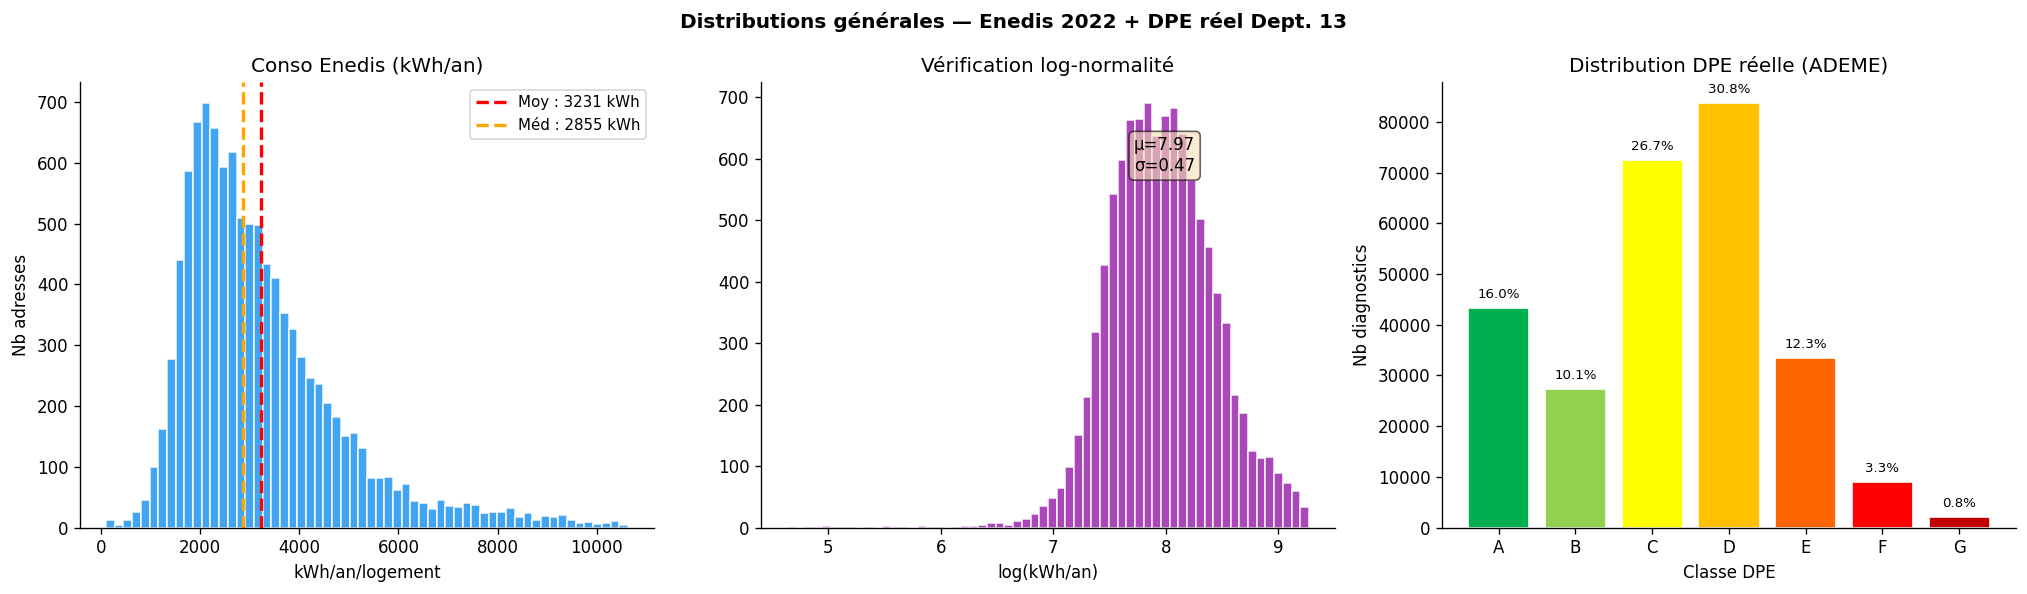


→ La consommation Enedis suit une loi log-normale (typique des consommations résidentielles).
→ Le parc DPE est concentré en classes C–E (70% du parc).


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Distributions générales — Enedis 2022 + DPE réel Dept. 13",
             fontsize=12, fontweight="bold")

# Conso Enedis
axes[0].hist(df["conso_moy_kwh"], bins=60, color="#2196F3", alpha=0.85, edgecolor="white")
axes[0].axvline(df["conso_moy_kwh"].mean(),   color="red",    ls="--", lw=2,
                label=f"Moy : {df['conso_moy_kwh'].mean():.0f} kWh")
axes[0].axvline(df["conso_moy_kwh"].median(), color="orange", ls="--", lw=2,
                label=f"Méd : {df['conso_moy_kwh'].median():.0f} kWh")
axes[0].set_xlabel("kWh/an/logement"); axes[0].set_ylabel("Nb adresses")
axes[0].set_title("Conso Enedis (kWh/an)"); axes[0].legend(fontsize=9)

# Conso log-normale
axes[1].hist(df["log_conso"], bins=60, color="#9C27B0", alpha=0.85, edgecolor="white")
axes[1].set_xlabel("log(kWh/an)"); axes[1].set_title("Vérification log-normalité")
axes[1].annotate(f"μ={df['log_conso'].mean():.2f}\nσ={df['log_conso'].std():.2f}",
                 xy=(0.65, 0.80), xycoords="axes fraction",
                 bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.6))

# Distribution DPE
dist_cls = dpe["classe_dpe"].value_counts().reindex(CLASSES_DPE).fillna(0)
total = dist_cls.sum()
bars = axes[2].bar(CLASSES_DPE, dist_cls,
                   color=[PALETTE_DPE[c] for c in CLASSES_DPE], edgecolor="white")
for b, n in zip(bars, dist_cls):
    axes[2].text(b.get_x()+b.get_width()/2, b.get_height()+total*0.005,
                 f"{n/total*100:.1f}%", ha="center", va="bottom", fontsize=8)
axes[2].set_xlabel("Classe DPE"); axes[2].set_ylabel("Nb diagnostics")
axes[2].set_title("Distribution DPE réelle (ADEME)")

plt.tight_layout()
plt.savefig(f"{OUTDIR}/fig1_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n→ La consommation Enedis suit une loi log-normale (typique des consommations résidentielles).")
print(f"→ Le parc DPE est concentré en classes C–E ({(dist_cls[['C','D','E']].sum()/total*100):.0f}% du parc).")


### 6.2 Consommation par classe DPE — Boxplots

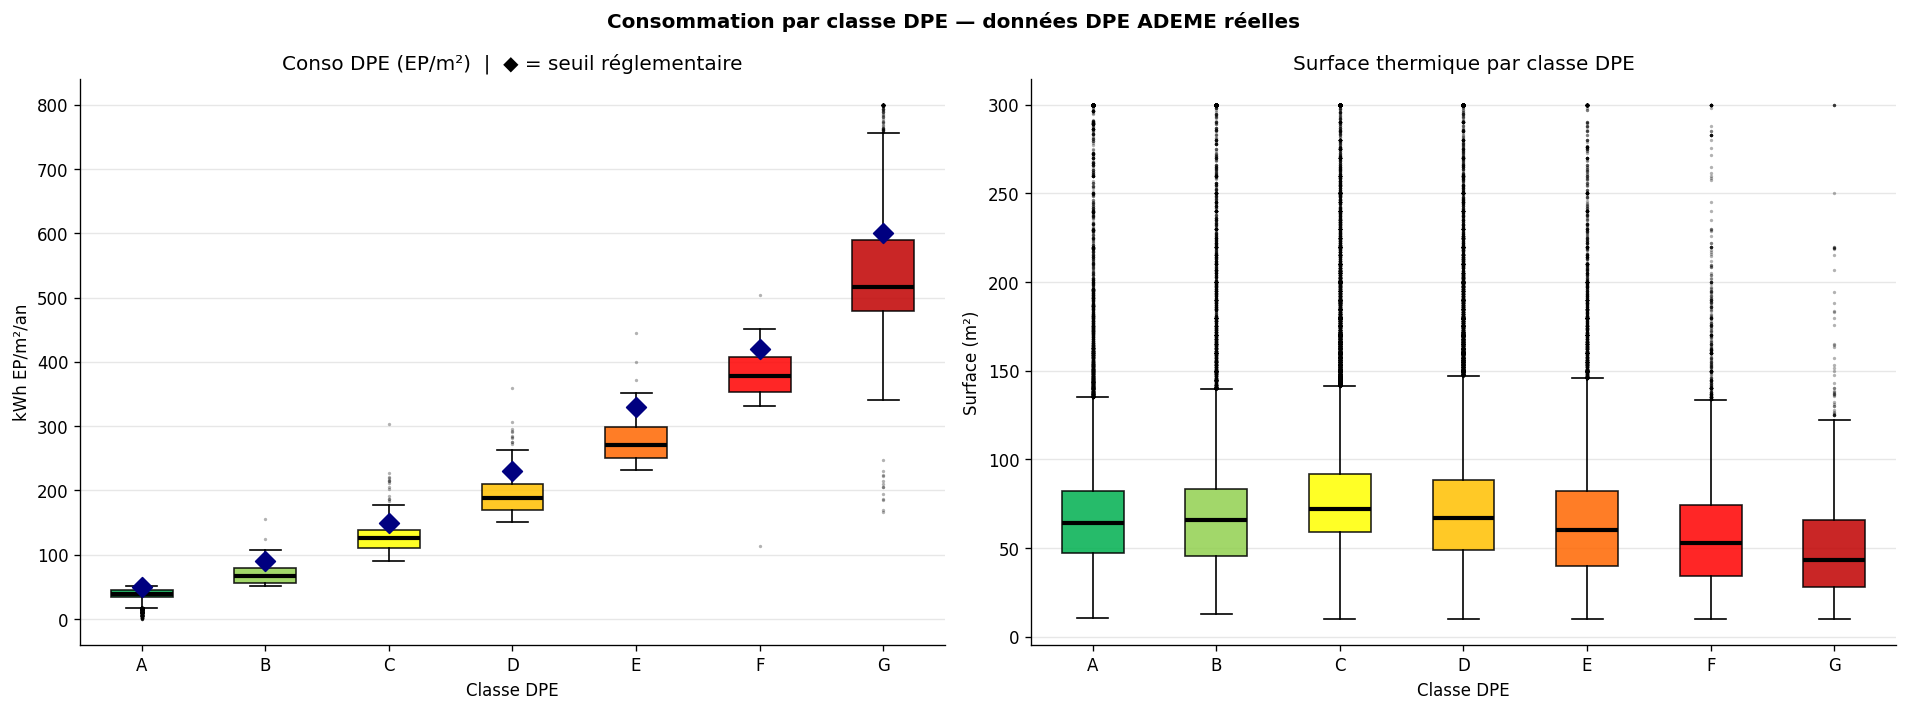


→ Les seuils réglementaires sont bien respectés en médiane.
→ La surface croît légèrement de G vers A : les logements bien classés sont souvent plus grands.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Consommation par classe DPE — données DPE ADEME réelles",
             fontsize=12, fontweight="bold")

# kWh EP/m²/an (données DPE)
bp = axes[0].boxplot(
    [dpe[dpe["classe_dpe"]==c]["conso_ep_m2"].clip(0,800).values for c in CLASSES_DPE],
    labels=CLASSES_DPE, patch_artist=True,
    medianprops=dict(color="black", lw=2.5),
    flierprops=dict(marker=".", markersize=2, alpha=0.3)
)
for patch, c in zip(bp["boxes"], CLASSES_DPE):
    patch.set_facecolor(PALETTE_DPE[c]); patch.set_alpha(0.85)
# Seuils réglementaires
seuils = {"A":50,"B":90,"C":150,"D":230,"E":330,"F":420,"G":600}
for i, c in enumerate(CLASSES_DPE):
    axes[0].scatter(i+1, seuils[c], marker="D", color="navy", s=70, zorder=5)
axes[0].set_xlabel("Classe DPE"); axes[0].set_ylabel("kWh EP/m²/an")
axes[0].set_title("Conso DPE (EP/m²)  |  ◆ = seuil réglementaire")
axes[0].yaxis.grid(True, alpha=0.3); axes[0].set_axisbelow(True)

# Surface par classe
bp2 = axes[1].boxplot(
    [dpe[dpe["classe_dpe"]==c]["surface_m2"].clip(0,300).values for c in CLASSES_DPE],
    labels=CLASSES_DPE, patch_artist=True,
    medianprops=dict(color="black", lw=2.5),
    flierprops=dict(marker=".", markersize=2, alpha=0.3)
)
for patch, c in zip(bp2["boxes"], CLASSES_DPE):
    patch.set_facecolor(PALETTE_DPE[c]); patch.set_alpha(0.85)
axes[1].set_xlabel("Classe DPE"); axes[1].set_ylabel("Surface (m²)")
axes[1].set_title("Surface thermique par classe DPE")
axes[1].yaxis.grid(True, alpha=0.3); axes[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig(f"{OUTDIR}/fig2_boxplots_dpe.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n→ Les seuils réglementaires sont bien respectés en médiane.")
print("→ La surface croît légèrement de G vers A : les logements bien classés sont souvent plus grands.")


### 6.3 Consommation estimée (DPE) vs réelle (Enedis)

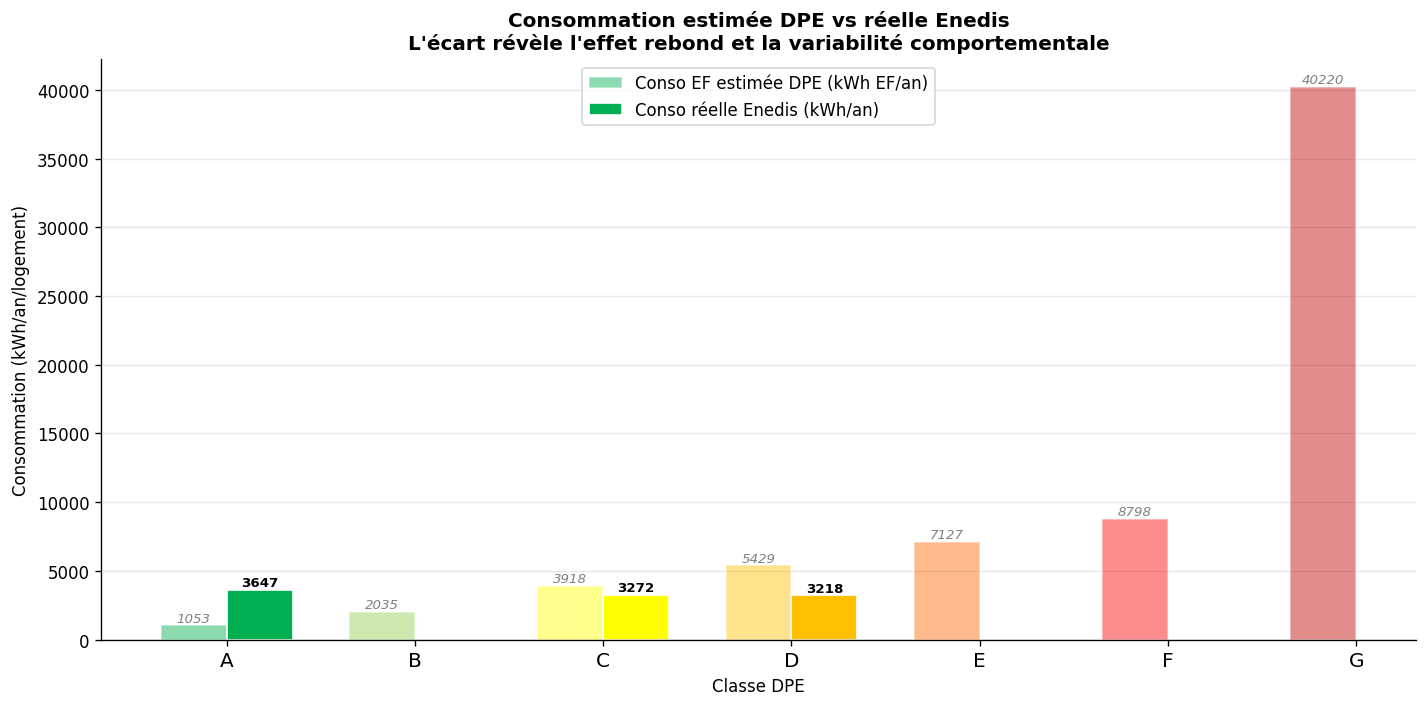


→ L'écart entre estimation et réalité est l'empreinte de l'effet rebond :
  les occupants de logements bien classés DPE maintiennent des températures plus élevées
  ou possèdent plus d'équipements électriques.


In [17]:
conso_ef_par_classe    = dpe.groupby("classe_dpe")["conso_ef_kwh_est"].mean().reindex(CLASSES_DPE)
conso_reel_par_classe  = df.groupby("classe_dpe_mode")["conso_moy_kwh"].mean().reindex(CLASSES_DPE)

fig, ax = plt.subplots(figsize=(12, 6))
x, w = np.arange(7), 0.35
b1 = ax.bar(x-w/2, conso_ef_par_classe, w,
            color=[PALETTE_DPE[c] for c in CLASSES_DPE],
            alpha=0.45, label="Conso EF estimée DPE (kWh EF/an)", edgecolor="white")
b2 = ax.bar(x+w/2, conso_reel_par_classe, w,
            color=[PALETTE_DPE[c] for c in CLASSES_DPE],
            alpha=1.0, label="Conso réelle Enedis (kWh/an)", edgecolor="white")
for bar in b1:
    if bar.get_height() > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                f"{bar.get_height():.0f}", ha="center", va="bottom",
                fontsize=8, color="gray", style="italic")
for bar in b2:
    if bar.get_height() > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                f"{bar.get_height():.0f}", ha="center", va="bottom",
                fontsize=8, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(CLASSES_DPE, fontsize=12)
ax.set_xlabel("Classe DPE"); ax.set_ylabel("Consommation (kWh/an/logement)")
ax.set_title("Consommation estimée DPE vs réelle Enedis\n"
             "L'écart révèle l'effet rebond et la variabilité comportementale",
             fontweight="bold")
ax.legend(fontsize=10); ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(f"{OUTDIR}/fig3_estime_vs_reel.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n→ L'écart entre estimation et réalité est l'empreinte de l'effet rebond :")
print("  les occupants de logements bien classés DPE maintiennent des températures plus élevées")
print("  ou possèdent plus d'équipements électriques.")


### 6.4 Distributions détaillées et corrélations

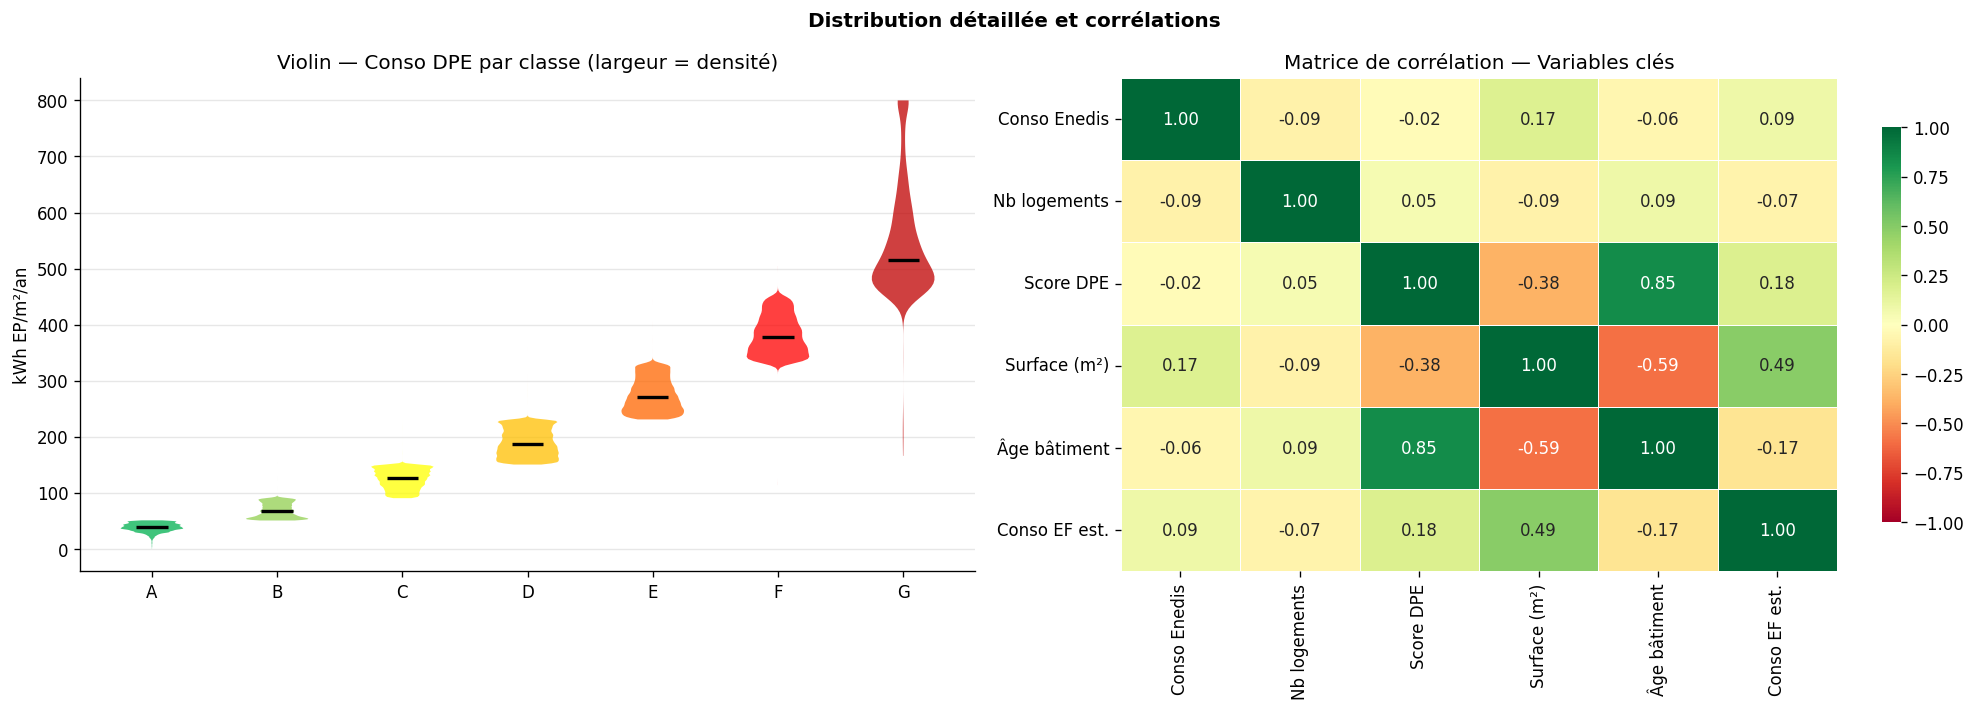


→ Corrélations clés :
Surface (m²)     0.173
Conso EF est.    0.091
Nb logements    -0.085
Âge bâtiment    -0.060
Score DPE       -0.025


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle("Distribution détaillée et corrélations", fontsize=12, fontweight="bold")

# Violin — conso EP/m²
vp = axes[0].violinplot(
    [dpe[dpe["classe_dpe"]==c]["conso_ep_m2"].clip(0,800).values for c in CLASSES_DPE],
    positions=range(7), showmedians=True, showextrema=False
)
for body, c in zip(vp["bodies"], CLASSES_DPE):
    body.set_facecolor(PALETTE_DPE[c]); body.set_alpha(0.75)
vp["cmedians"].set_color("black"); vp["cmedians"].set_lw(2)
axes[0].set_xticks(range(7)); axes[0].set_xticklabels(CLASSES_DPE)
axes[0].set_ylabel("kWh EP/m²/an")
axes[0].set_title("Violin — Conso DPE par classe (largeur = densité)")
axes[0].yaxis.grid(True, alpha=0.3); axes[0].set_axisbelow(True)

# Heatmap corrélations
num_cols = ["conso_moy_kwh","nb_logements","score_dpe_moy",
            "surface_moy","age_bat_moy","conso_ef_moy"]
labels   = ["Conso Enedis","Nb logements","Score DPE",
            "Surface (m²)","Âge bâtiment","Conso EF est."]
corr_m   = df[num_cols].set_axis(labels, axis=1).corr()
sns.heatmap(corr_m, ax=axes[1], annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
axes[1].set_title("Matrice de corrélation — Variables clés")

plt.tight_layout()
plt.savefig(f"{OUTDIR}/fig4_violin_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n→ Corrélations clés :")
print(corr_m["Conso Enedis"].drop("Conso Enedis").sort_values(key=abs, ascending=False).round(3).to_string())


### 6.5 Relation DPE — Conso Enedis & Évolution temporelle

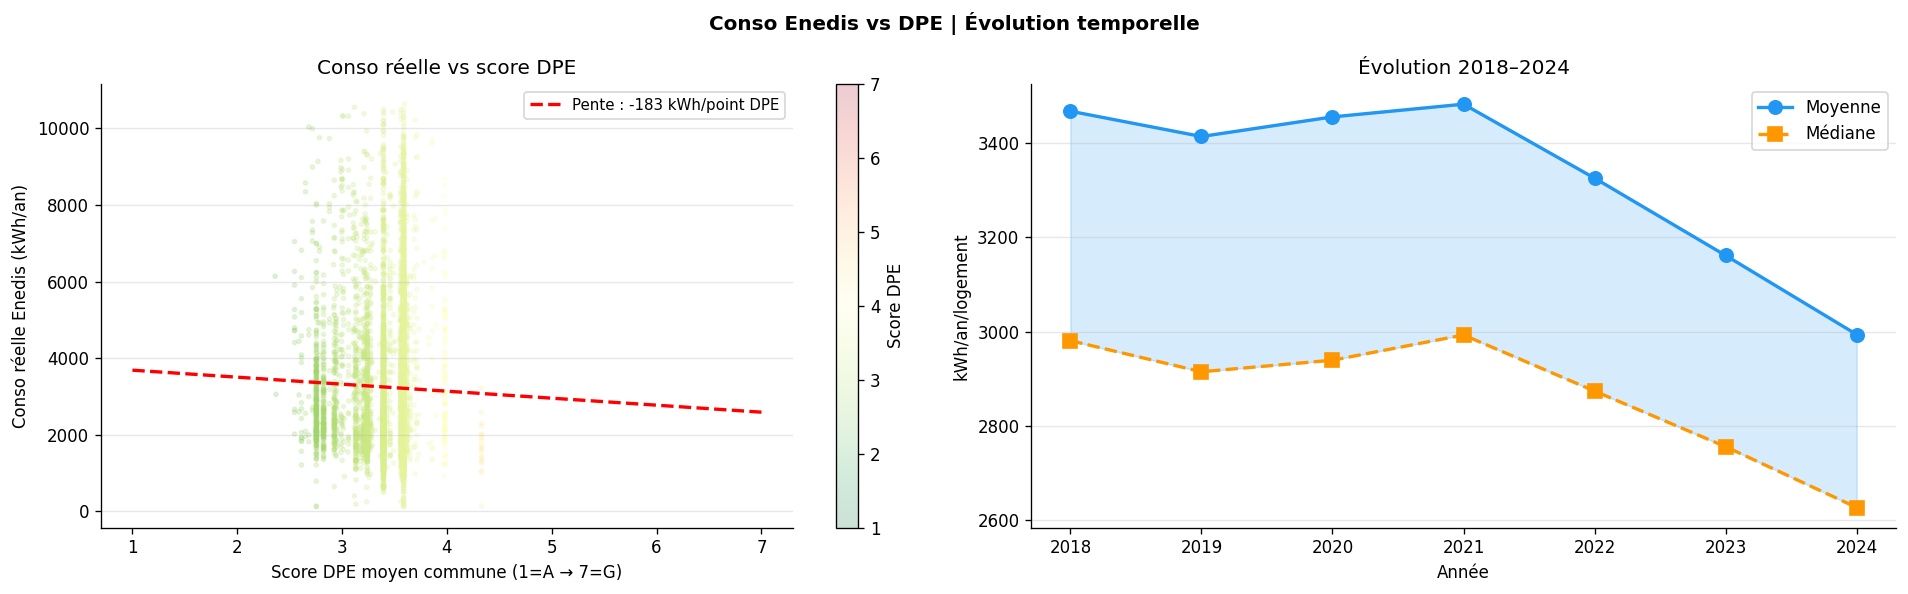

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Conso Enedis vs DPE | Évolution temporelle", fontsize=12, fontweight="bold")

# Scatter : score DPE vs conso Enedis
sc = axes[0].scatter(df["score_dpe_moy"], df["conso_moy_kwh"],
                     alpha=0.2, s=6, c=df["score_dpe_moy"],
                     cmap="RdYlGn_r", vmin=1, vmax=7)
plt.colorbar(sc, ax=axes[0], label="Score DPE")
m = np.polyfit(df["score_dpe_moy"].fillna(4), df["conso_moy_kwh"], 1)
xr = np.linspace(1, 7, 100)
axes[0].plot(xr, np.polyval(m, xr), "r--", lw=2,
             label=f"Pente : {m[0]:+.0f} kWh/point DPE")
axes[0].set_xlabel("Score DPE moyen commune (1=A → 7=G)")
axes[0].set_ylabel("Conso réelle Enedis (kWh/an)")
axes[0].set_title("Conso réelle vs score DPE")
axes[0].legend(fontsize=9); axes[0].yaxis.grid(True, alpha=0.3)

# Évolution Enedis
evol = conso.groupby("annee")["conso_moy_site_mwh"].agg(["mean", "median"]).reset_index()
evol["moy_kwh"] = evol["mean"]*1000
evol["med_kwh"] = evol["median"]*1000
axes[1].plot(evol["annee"], evol["moy_kwh"], "o-", color="#2196F3", lw=2, ms=8, label="Moyenne")
axes[1].plot(evol["annee"], evol["med_kwh"], "s--", color="#FF9800", lw=2, ms=8, label="Médiane")
axes[1].fill_between(evol["annee"], evol["moy_kwh"], evol["med_kwh"], alpha=0.18, color="#2196F3")
axes[1].set_xlabel("Année"); axes[1].set_ylabel("kWh/an/logement")
axes[1].set_title("Évolution 2018–2024"); axes[1].legend()
axes[1].set_xticks(evol["annee"]); axes[1].yaxis.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTDIR}/fig5_scatter_evol.png", dpi=150, bbox_inches="tight")
plt.show()


### 6.6 Analyse par commune & Variabilité comportementale

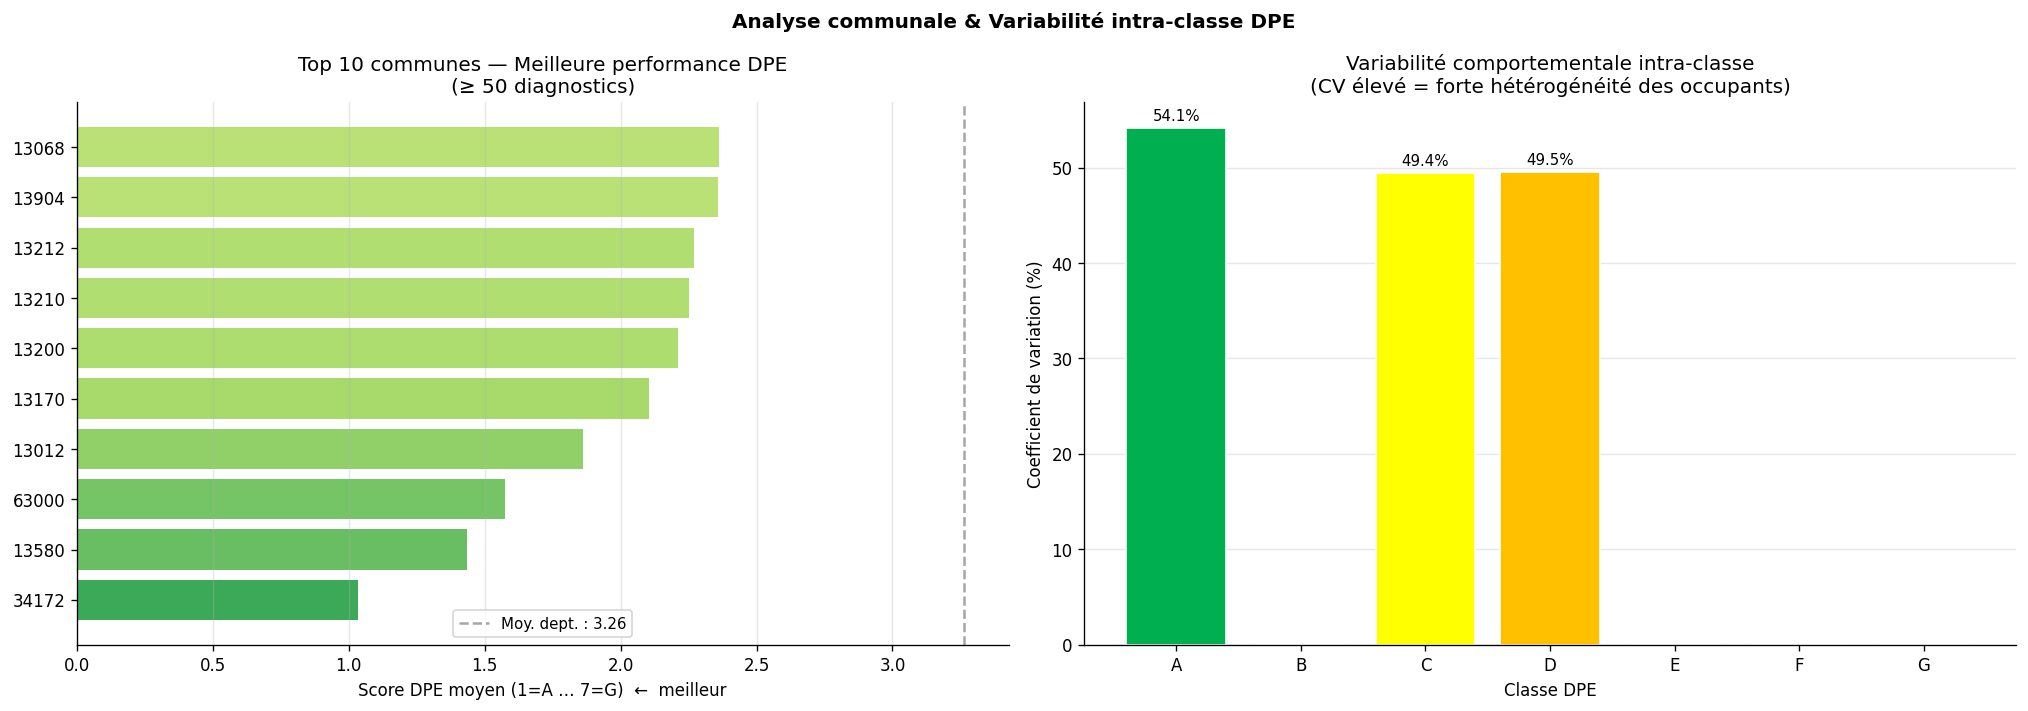


→ Un CV > 40 % signifie que deux logements de même classe DPE peuvent consommer
  jusqu'à 2–3x différemment selon le comportement de leurs occupants.


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle("Analyse communale & Variabilité intra-classe DPE", fontweight="bold")

# Top communes par score DPE
com_dpe = dpe.groupby("code_insee").agg(
    n=("classe_dpe","count"), score=("score_dpe","mean")
).reset_index()
best_com = com_dpe[com_dpe["n"]>=50].nsmallest(10,"score")
clr_com  = [plt.cm.RdYlGn_r(s/7) for s in best_com["score"]]
axes[0].barh(best_com["code_insee"].astype(str), best_com["score"], color=clr_com)
axes[0].axvline(dpe["score_dpe"].mean(), color="gray", ls="--", alpha=0.7,
                label=f"Moy. dept. : {dpe['score_dpe'].mean():.2f}")
axes[0].set_xlabel("Score DPE moyen (1=A … 7=G)  ←  meilleur")
axes[0].set_title("Top 10 communes — Meilleure performance DPE\n(≥ 50 diagnostics)")
axes[0].legend(fontsize=9); axes[0].xaxis.grid(True, alpha=0.3)

# CV intra-classe
cv = df.groupby("classe_dpe_mode")["conso_moy_kwh"].apply(
    lambda x: x.std()/x.mean()*100
).reindex(CLASSES_DPE).fillna(0)
axes[1].bar(CLASSES_DPE, cv, color=[PALETTE_DPE[c] for c in CLASSES_DPE], edgecolor="white")
for i,(c,v) in enumerate(zip(CLASSES_DPE, cv)):
    if v > 0:
        axes[1].text(i, v+0.5, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
axes[1].set_xlabel("Classe DPE"); axes[1].set_ylabel("Coefficient de variation (%)")
axes[1].set_title("Variabilité comportementale intra-classe\n(CV élevé = forte hétérogénéité des occupants)")
axes[1].yaxis.grid(True, alpha=0.3); axes[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig(f"{OUTDIR}/fig6_communes_cv.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n→ Un CV > 40 % signifie que deux logements de même classe DPE peuvent consommer")
print("  jusqu'à 2–3x différemment selon le comportement de leurs occupants.")


## 7. Modélisation Prédictive

### Variables explicatives
| Feature | Description |
|---|---|
| `score_dpe_moy` | Score DPE moyen de la commune (1=A … 7=G) |
| `nb_logements` | Nombre de logements dans l'adresse |
| `surface_moy` | Surface thermique moyenne (m²) |
| `age_bat_moy` | Âge moyen du bâtiment (ans) |
| `commune_num` | Commune encodée (top 20 + Autres) |
| `cat_immeuble_num` | Taille de l'immeuble (catégorie ordinale) |
| `pct_F`, `pct_G` | % de logements en classe F/G dans la commune |

**Modèles :** Ridge Regression · Random Forest · Gradient Boosting  
**Évaluation :** MAE, RMSE, R² sur 20% de données test


In [32]:
FEATURES = ["score_dpe_moy","nb_logements","surface_moy","age_bat_moy",
            "commune_num","cat_immeuble_num","pct_F","pct_G"]
TARGET   = "conso_moy_kwh"
FEAT_LBL = ["Score DPE","Nb logements","Surface (m²)","Âge bâtiment",
            "Commune","Taille immeuble","% classe F","% classe G"]

X = df[FEATURES].fillna(df[FEATURES].median())
y = df[TARGET]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=SEED)
sc  = StandardScaler()
X_tr_sc, X_te_sc = sc.fit_transform(X_tr), sc.transform(X_te)

models_cfg = {
    "Ridge":           (Ridge(alpha=1.0),                                              True),
    "Random Forest":   (RandomForestRegressor(n_estimators = 200, max_depth=12,
                          min_samples_leaf=5, random_state=SEED, n_jobs=-1),           False),
    "Gradient Boost":  (GradientBoostingRegressor(n_estimators=300, max_depth=5,
                          learning_rate=0.05, subsample=0.8, random_state=SEED),       False),
}

results = {}
print(f"{'Modèle':22s} | {'MAE':>8s} | {'RMSE':>8s} | {'R²':>8s}")
print("-" * 55)
for name, (model, scaled) in models_cfg.items():
    Xtr, Xte = (X_tr_sc, X_te_sc) if scaled else (X_tr, X_te)
    model.fit(Xtr, y_tr)
    yp  = model.predict(Xte)
    mae  = mean_absolute_error(y_te, yp)
    rmse = np.sqrt(mean_squared_error(y_te, yp))
    r2   = r2_score(y_te, yp)
    results[name] = {"model": model, "y_pred": yp, "MAE": mae, "RMSE": rmse, "R2": r2}
    print(f"{name:22s} | {mae:>6.0f} kWh | {rmse:>6.0f} kWh | {r2:>8.4f}")

best_name = max(results, key=lambda x: results[x]["R2"])
best = results[best_name]
print(f"\n✅ Meilleur modèle : {best_name}  (R² = {best['R2']:.4f})")


Modèle                 |      MAE |     RMSE |       R²
-------------------------------------------------------
Ridge                  |   1153 kWh |   1555 kWh |   0.0412
Random Forest          |   1133 kWh |   1548 kWh |   0.0501
Gradient Boost         |   1133 kWh |   1546 kWh |   0.0527

✅ Meilleur modèle : Gradient Boost  (R² = 0.0527)


### 7.1 Comparaison des performances & Analyse des résidus

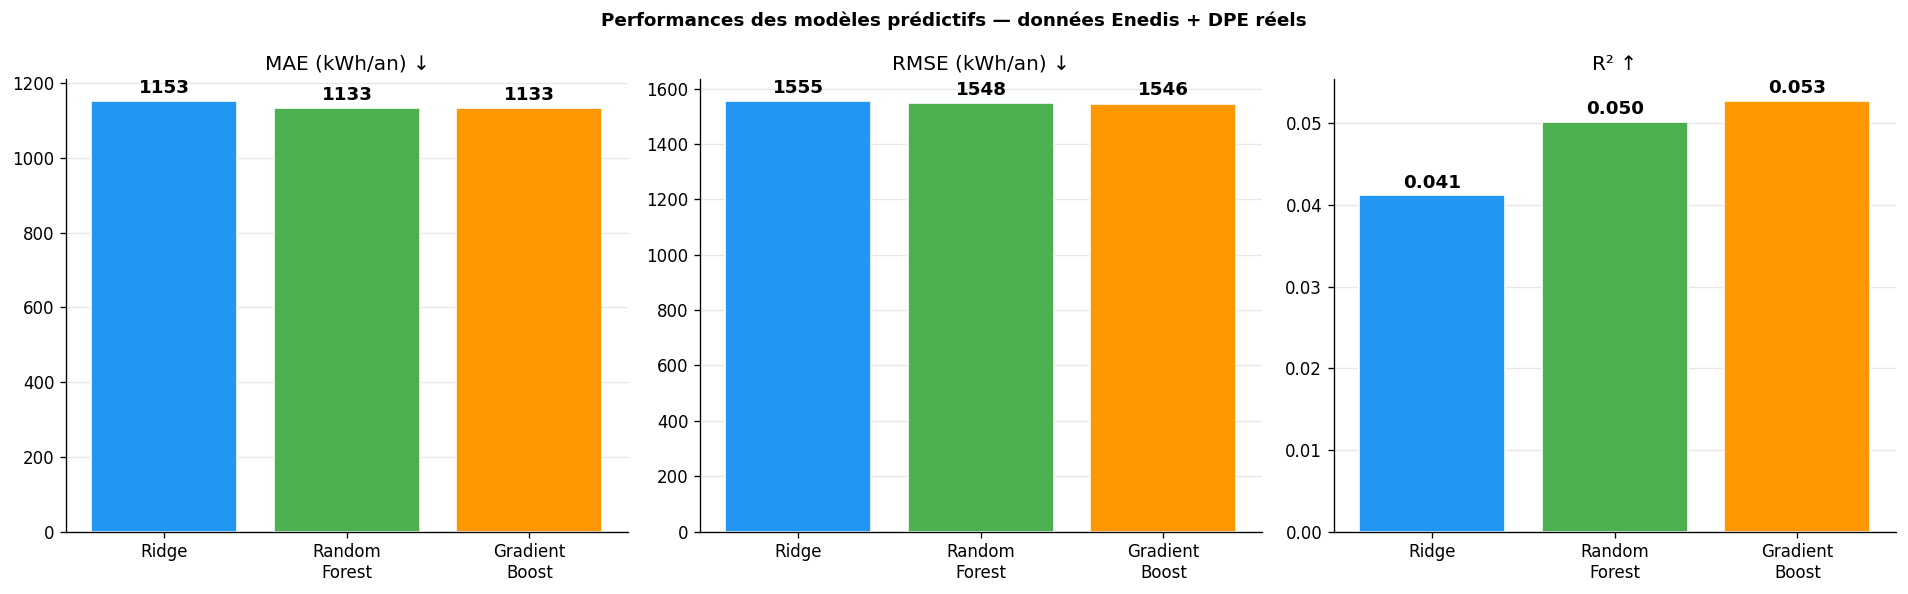

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Performances des modèles prédictifs — données Enedis + DPE réels",
             fontsize=11, fontweight="bold")

nms = list(results.keys())
mc  = ["#2196F3","#4CAF50","#FF9800"]
for ax, metric, title in zip(axes, ["MAE","RMSE","R2"],
                              ["MAE (kWh/an) ↓","RMSE (kWh/an) ↓","R² ↑"]):
    vals = [results[m][metric] for m in nms]
    bars = ax.bar(["Ridge","Random\nForest","Gradient\nBoost"], vals,
                  color=mc, edgecolor="white")
    fmt  = "{:.3f}" if metric == "R2" else "{:.0f}"
    [ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.01,
             fmt.format(v), ha="center", va="bottom", fontweight="bold", fontsize=11)
     for b, v in zip(bars, vals)]
    ax.set_title(title); ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(f"{OUTDIR}/fig7_perf_modeles.png", dpi=150, bbox_inches="tight")
plt.show()


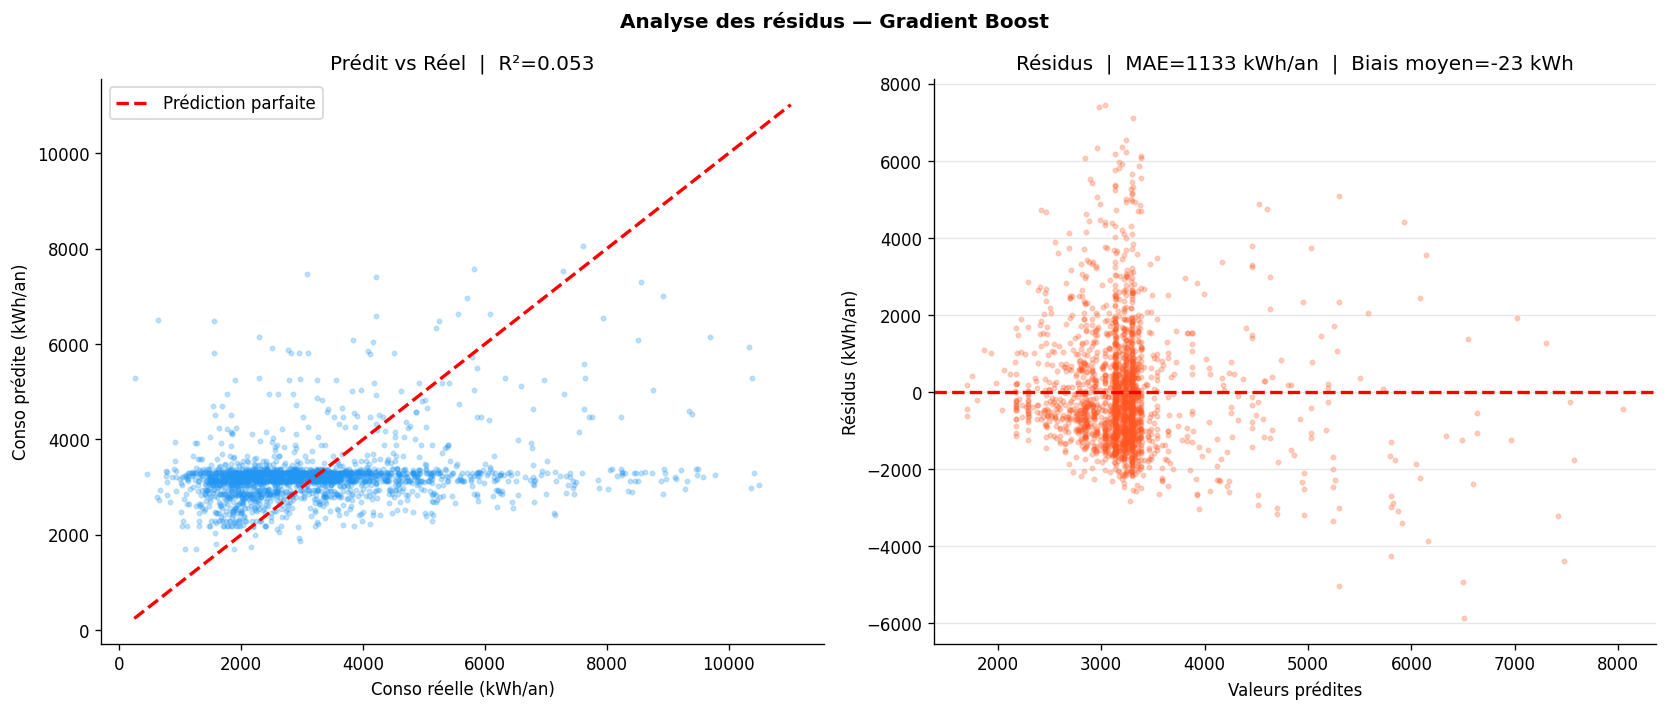


→ Biais moyen des résidus : -23.3 kWh
→ 90% des erreurs sont inférieures à 2298 kWh/an


In [34]:
yp_best = best["y_pred"]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"Analyse des résidus — {best_name}", fontsize=12, fontweight="bold")

axes[0].scatter(y_te, yp_best, alpha=0.25, s=7, c="#2196F3")
lm = [min(y_te.min(), yp_best.min())*0.95, max(y_te.max(), yp_best.max())*1.05]
axes[0].plot(lm, lm, "r--", lw=2, label="Prédiction parfaite")
axes[0].set_xlabel("Conso réelle (kWh/an)"); axes[0].set_ylabel("Conso prédite (kWh/an)")
axes[0].set_title(f"Prédit vs Réel  |  R²={best['R2']:.3f}"); axes[0].legend()

res = y_te.values - yp_best
axes[1].scatter(yp_best, res, alpha=0.25, s=7, c="#FF5722")
axes[1].axhline(0, color="red", lw=2, ls="--")
axes[1].set_xlabel("Valeurs prédites"); axes[1].set_ylabel("Résidus (kWh/an)")
axes[1].set_title(f"Résidus  |  MAE={best['MAE']:.0f} kWh/an  |  Biais moyen={res.mean():.0f} kWh")
axes[1].yaxis.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTDIR}/fig8_residus.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n→ Biais moyen des résidus : {res.mean():.1f} kWh")
print(f"→ 90% des erreurs sont inférieures à {np.percentile(np.abs(res), 90):.0f} kWh/an")


## 8. Importance des Variables

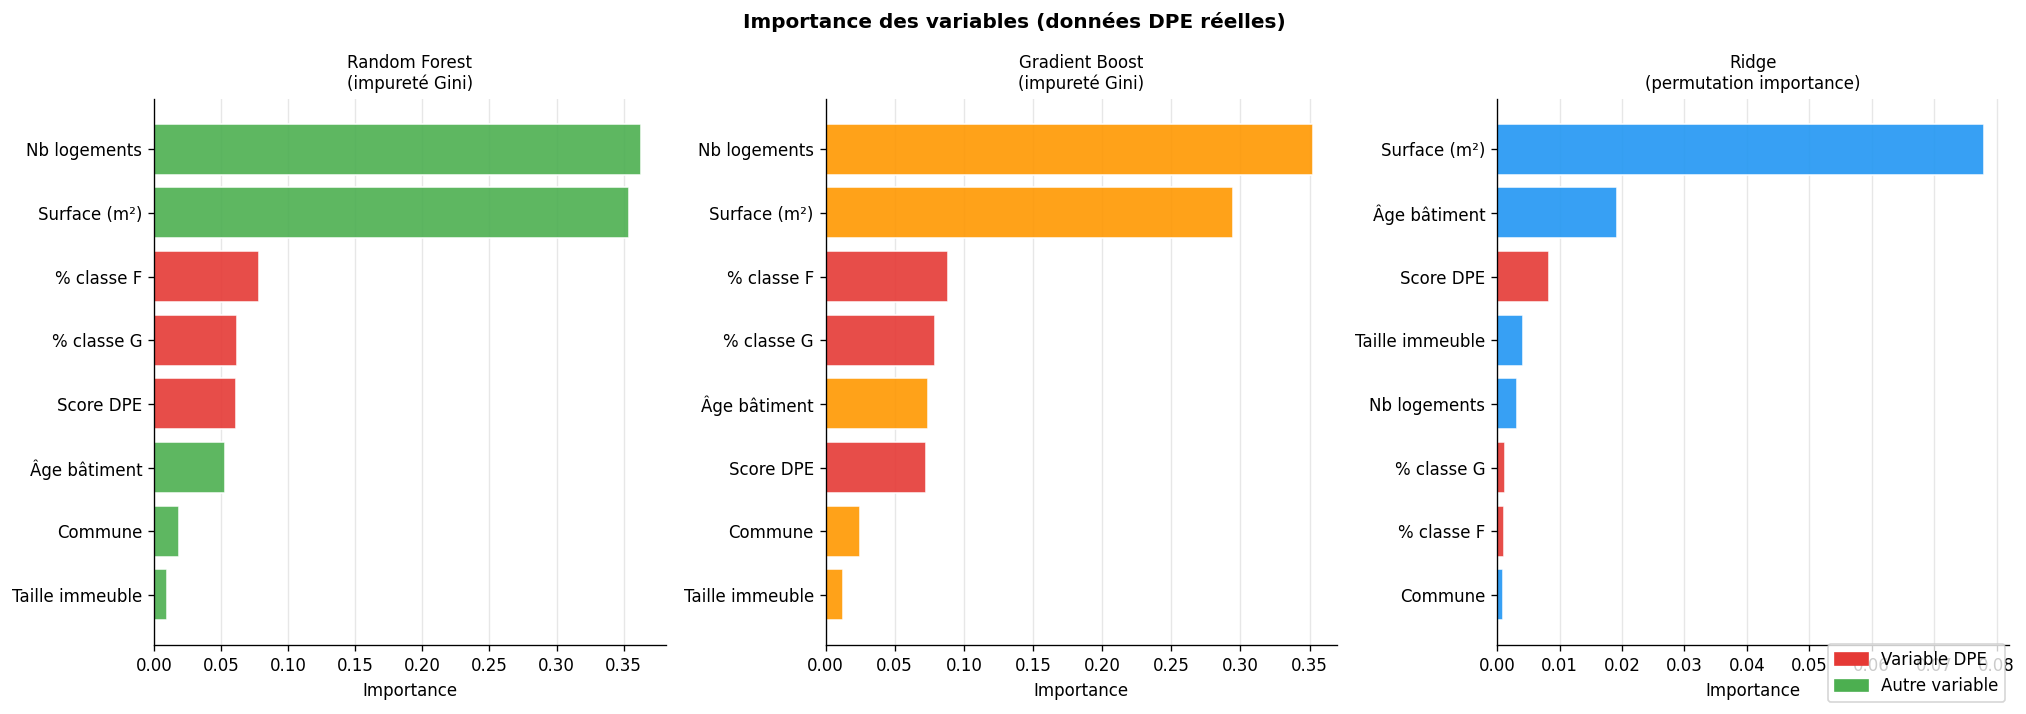


Importance Random Forest (triée) :
Nb logements       0.3631
Surface (m²)       0.3540
% classe F         0.0781
% classe G         0.0617
Score DPE          0.0614
Âge bâtiment       0.0531
Commune            0.0189
Taille immeuble    0.0096

→ Le score DPE représente 6.1% de l'importance totale (RF).


In [35]:
rf = results["Random Forest"]["model"]
gb = results["Gradient Boost"]["model"]

fi_rf = pd.Series(rf.feature_importances_, index=FEAT_LBL).sort_values(ascending=True)
fi_gb = pd.Series(gb.feature_importances_, index=FEAT_LBL).sort_values(ascending=True)
perm  = permutation_importance(results["Ridge"]["model"], X_te_sc, y_te,
                                n_repeats=10, random_state=SEED)
fi_ri = pd.Series(perm.importances_mean, index=FEAT_LBL).sort_values(ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle("Importance des variables (données DPE réelles)", fontsize=12, fontweight="bold")

for ax, fi, title, base_color in zip(
    axes, [fi_rf, fi_gb, fi_ri],
    ["Random Forest\n(impureté Gini)", "Gradient Boost\n(impureté Gini)",
     "Ridge\n(permutation importance)"],
    ["#4CAF50","#FF9800","#2196F3"]
):
    clrs = ["#E53935" if "DPE" in n or "classe" in n.lower() else base_color
            for n in fi.index]
    ax.barh(fi.index, fi.values, color=clrs, alpha=0.9, edgecolor="white")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Importance")
    ax.xaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
    ax.axvline(0, color="black", lw=0.5)

from matplotlib.patches import Patch
fig.legend(handles=[Patch(color="#E53935", label="Variable DPE"),
                    Patch(color="#4CAF50", label="Autre variable")],
           loc="lower right", bbox_to_anchor=(0.99, 0.01))
plt.tight_layout()
plt.savefig(f"{OUTDIR}/fig9_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nImportance Random Forest (triée) :")
print(fi_rf.sort_values(ascending=False).round(4).to_string())
print(f"\n→ Le score DPE représente {fi_rf['Score DPE']*100:.1f}% de l'importance totale (RF).")


## 9. Analyse de l'Impact du DPE — Gains Énergétiques & Financiers

Calculé sur la consommation EF estimée par les DPE réels (kWh EF/an/logement).


In [36]:
# Statistiques EF par classe (données DPE réelles)
stats_ef_num = dpe.groupby("classe_dpe")["conso_ef_kwh_est"].agg(
    ["mean","median","std","count"]
).reindex(CLASSES_DPE)
stats_ef_num.columns = ["Moyenne","Médiane","Std","N"]

print("=== Consommation EF estimée par classe (kWh EF/an/logement) ===")
print(stats_ef_num.round(0).to_string())

print(f"\n{'Transition':12s} | {'Gain kWh/an':>14s} | {'Gain €/an':>12s}")
print("-" * 45)
gains = {}
for i in range(len(CLASSES_DPE)-1):
    c1, c2 = CLASSES_DPE[i+1], CLASSES_DPE[i]
    g_kwh = stats_ef_num.loc[c1,"Moyenne"] - stats_ef_num.loc[c2,"Moyenne"]
    g_eur = g_kwh * PRIX_KWH
    gains[f"{c1}→{c2}"] = {"kwh": g_kwh, "eur": g_eur, "de": c1}
    print(f"  {c1} → {c2}   | {g_kwh:>12.0f} kWh | {g_eur:>10.0f} €")

g_GA_kwh = stats_ef_num.loc["G","Moyenne"] - stats_ef_num.loc["A","Moyenne"]
g_GA_eur = g_GA_kwh * PRIX_KWH
print(f"\n  G → A   | {g_GA_kwh:>12.0f} kWh | {g_GA_eur:>10.0f} €  ← rénovation complète")


=== Consommation EF estimée par classe (kWh EF/an/logement) ===
            Moyenne  Médiane       Std      N
classe_dpe                                   
A            1053.0    952.0     640.0  43345
B            2035.0   1712.0    1505.0  27419
C            3918.0   3456.0    2133.0  72553
D            5429.0   4843.0    3100.0  83654
E            7127.0   6295.0    4476.0  33534
F            8798.0   7743.0    5488.0   8982
G           40220.0   9075.0  523372.0   2045

Transition   |    Gain kWh/an |    Gain €/an
---------------------------------------------
  B → A   |          982 kWh |        247 €
  C → B   |         1882 kWh |        474 €
  D → C   |         1511 kWh |        380 €
  E → D   |         1698 kWh |        427 €
  F → E   |         1672 kWh |        421 €
  G → F   |        31422 kWh |       7906 €

  G → A   |        39167 kWh |       9854 €  ← rénovation complète


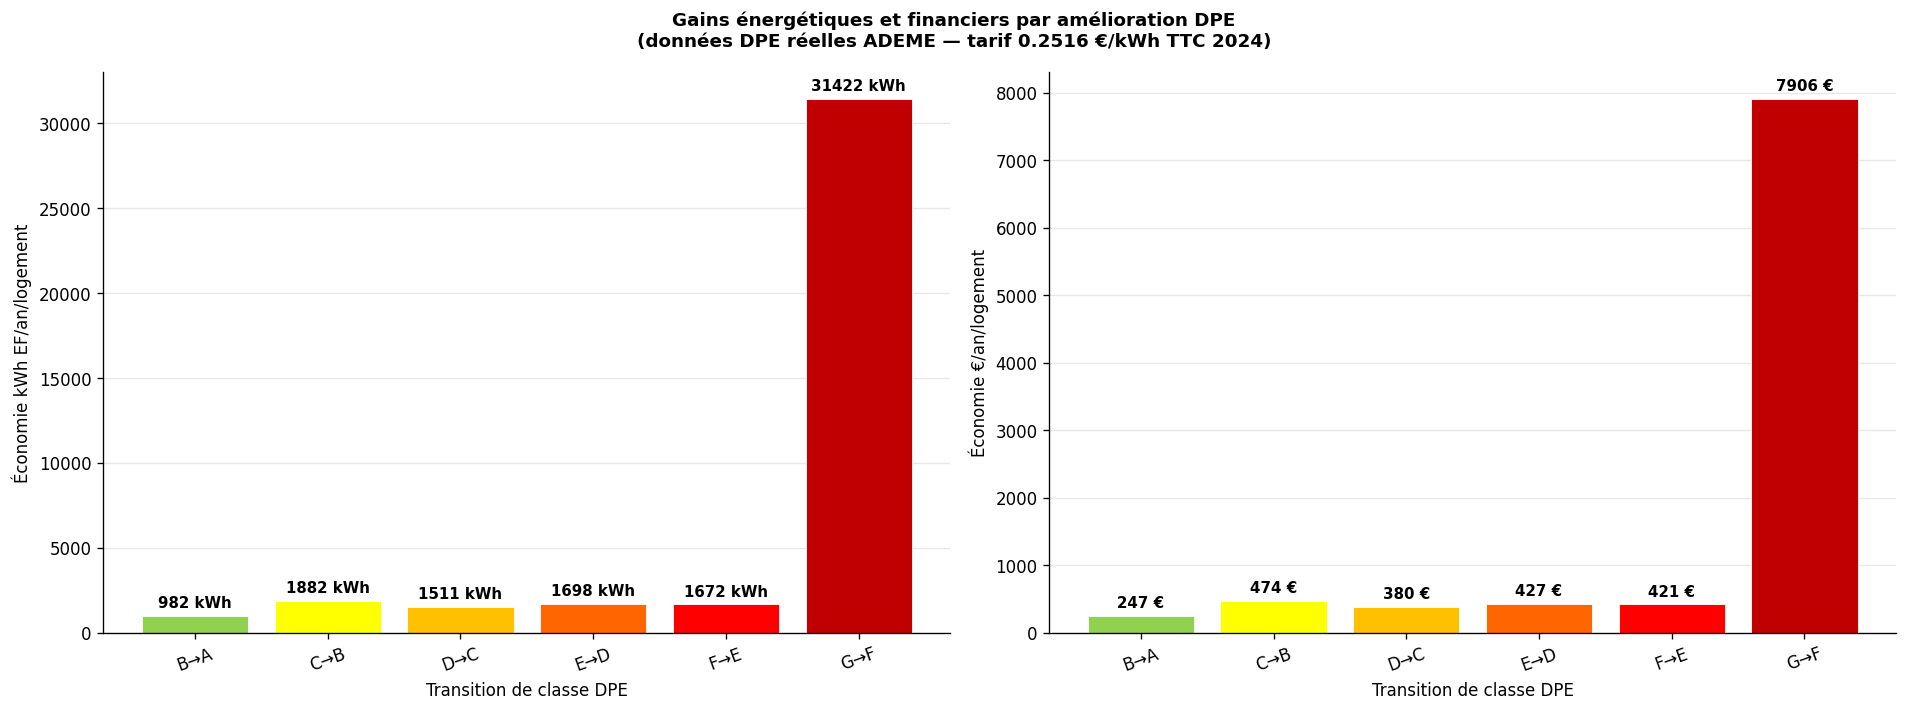

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"Gains énergétiques et financiers par amélioration DPE\n"
             f"(données DPE réelles ADEME — tarif {PRIX_KWH} €/kWh TTC 2024)",
             fontsize=11, fontweight="bold")

trans = list(gains.keys())
g_k   = [gains[t]["kwh"] for t in trans]
g_e   = [gains[t]["eur"] for t in trans]
clrs  = [PALETTE_DPE[gains[t]["de"]] for t in trans]

for ax, vals, ylabel, sfx in zip(
    axes, [g_k, g_e],
    ["Économie kWh EF/an/logement", "Économie €/an/logement"],
    [" kWh", " €"]
):
    bars = ax.bar(trans, vals, color=clrs, edgecolor="white", lw=0.5)
    [ax.text(b.get_x()+b.get_width()/2, b.get_height()+max(vals)*0.01,
             f"{v:.0f}{sfx}", ha="center", va="bottom",
             fontsize=9, fontweight="bold")
     for b, v in zip(bars, vals)]
    ax.set_xlabel("Transition de classe DPE"); ax.set_ylabel(ylabel)
    ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(f"{OUTDIR}/fig10_gains_transitions.png", dpi=150, bbox_inches="tight")
plt.show()


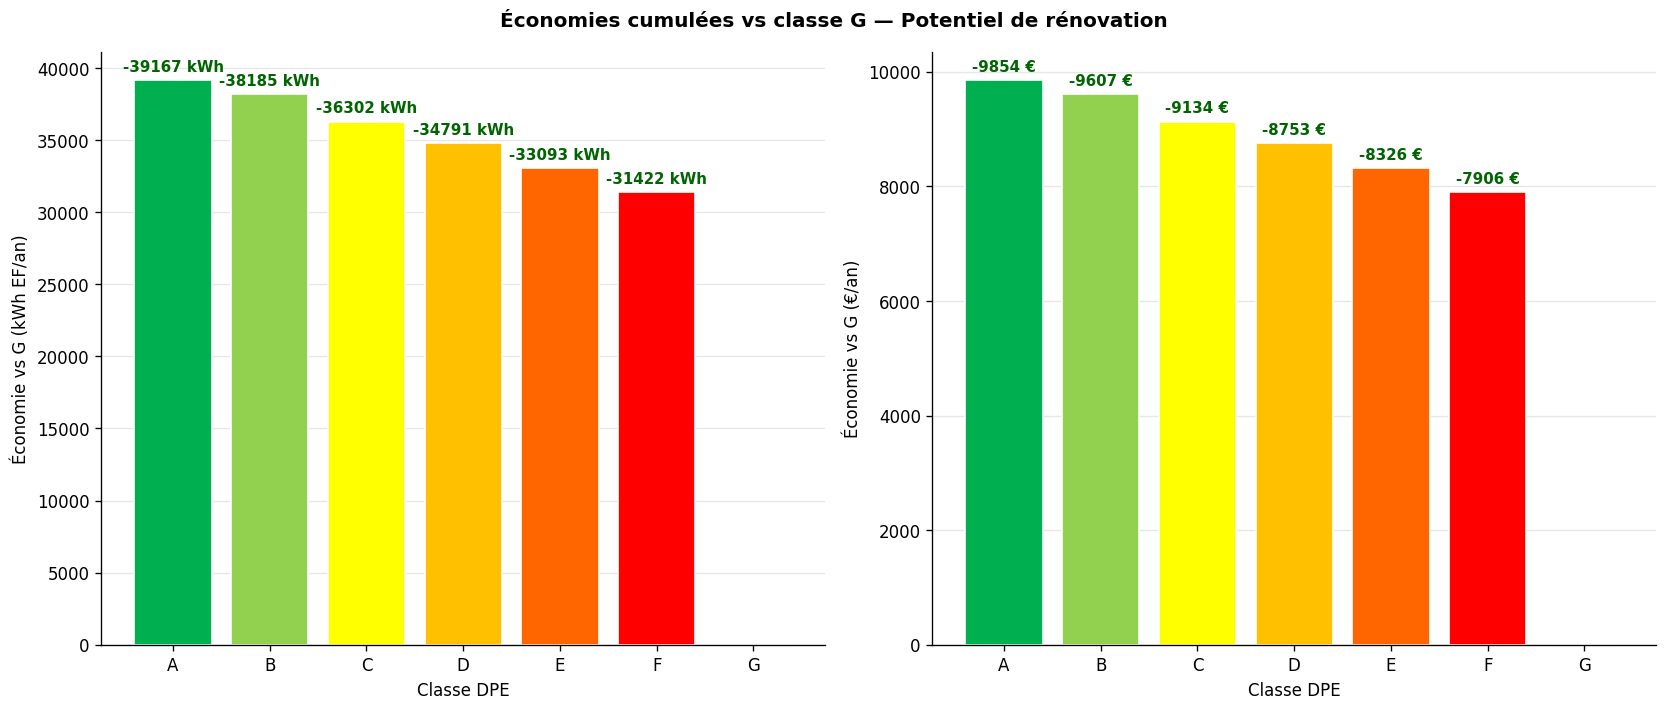

In [38]:
# Économies cumulées vs G
eco_vs_G = {c: stats_ef_num.loc["G","Moyenne"] - stats_ef_num.loc[c,"Moyenne"]
            for c in CLASSES_DPE}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Économies cumulées vs classe G — Potentiel de rénovation", fontweight="bold")
clr_b = [PALETTE_DPE[c] for c in CLASSES_DPE]

for ax, vals, ylabel, fmt in zip(
    axes,
    [list(eco_vs_G.values()), [v*PRIX_KWH for v in eco_vs_G.values()]],
    ["Économie vs G (kWh EF/an)", "Économie vs G (€/an)"],
    ["-{:.0f} kWh", "-{:.0f} €"]
):
    bars = ax.bar(CLASSES_DPE, vals, color=clr_b, edgecolor="white")
    [ax.text(b.get_x()+b.get_width()/2, b.get_height()+max(max(vals),1)*0.01,
             fmt.format(abs(v)), ha="center", va="bottom",
             fontsize=9, fontweight="bold", color="darkgreen")
     for b, v in zip(bars, vals) if v > 0]
    ax.set_xlabel("Classe DPE"); ax.set_ylabel(ylabel)
    ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(f"{OUTDIR}/fig11_gains_cumules.png", dpi=150, bbox_inches="tight")
plt.show()


### 9.1 Scénario de rénovation

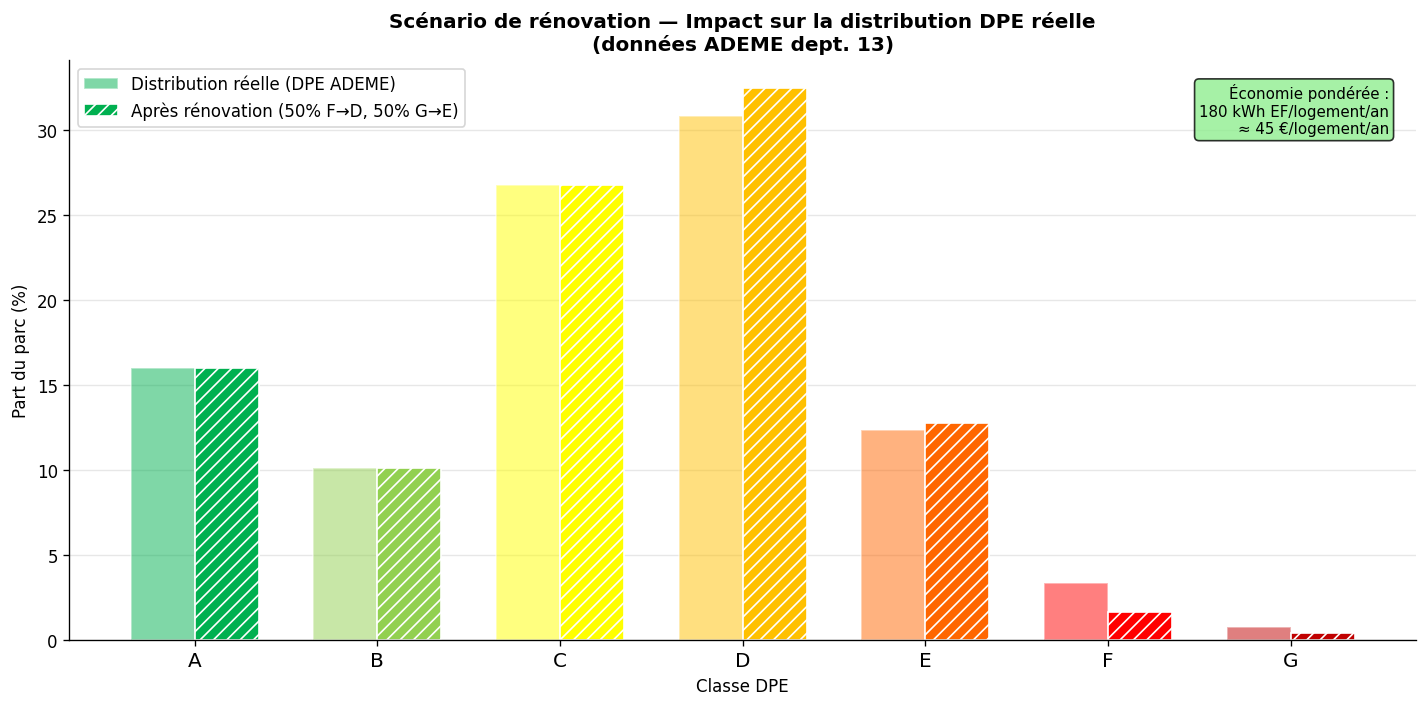


→ Les logements F et G représentent 4.1% du parc DPE analysé.
→ Rénover 50% d'entre eux permettrait d'économiser ~180 kWh/logement/an en moyenne,
  soit ~45 €/logement/an au tarif 2024.


In [39]:
dist_reel = dpe["classe_dpe"].value_counts(normalize=True).reindex(CLASSES_DPE).fillna(0)

# Scénario : 50% des logements F→D  et  50% des logements G→E
dist_sc = dist_reel.copy()
dist_sc["F"] -= dist_reel["F"] * 0.5
dist_sc["G"] -= dist_reel["G"] * 0.5
dist_sc["D"] += dist_reel["F"] * 0.5
dist_sc["E"] += dist_reel["G"] * 0.5

eco_sc = (
    dist_reel["F"] * 0.5 * (stats_ef_num.loc["F","Moyenne"] - stats_ef_num.loc["D","Moyenne"]) +
    dist_reel["G"] * 0.5 * (stats_ef_num.loc["G","Moyenne"] - stats_ef_num.loc["E","Moyenne"])
)

fig, ax = plt.subplots(figsize=(12, 6))
x, w = np.arange(7), 0.35
ax.bar(x-w/2, dist_reel*100, w,
       color=[PALETTE_DPE[c] for c in CLASSES_DPE],
       alpha=0.5, label="Distribution réelle (DPE ADEME)", edgecolor="white")
ax.bar(x+w/2, dist_sc*100, w,
       color=[PALETTE_DPE[c] for c in CLASSES_DPE],
       alpha=1.0, label="Après rénovation (50% F→D, 50% G→E)", edgecolor="white", hatch="///")
ax.set_xticks(x); ax.set_xticklabels(CLASSES_DPE, fontsize=12)
ax.set_ylabel("Part du parc (%)"); ax.set_xlabel("Classe DPE")
ax.set_title("Scénario de rénovation — Impact sur la distribution DPE réelle\n"
             "(données ADEME dept. 13)", fontweight="bold")
ax.legend(fontsize=10); ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
ax.text(0.98, 0.96,
        f"Économie pondérée :\n{eco_sc:.0f} kWh EF/logement/an\n≈ {eco_sc*PRIX_KWH:.0f} €/logement/an",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="lightgreen", alpha=0.8))
plt.tight_layout()
plt.savefig(f"{OUTDIR}/fig12_scenario.png", dpi=150, bbox_inches="tight")
plt.show()

pct_FG = (dist_reel["F"] + dist_reel["G"]) * 100
print(f"\n→ Les logements F et G représentent {pct_FG:.1f}% du parc DPE analysé.")
print(f"→ Rénover 50% d'entre eux permettrait d'économiser ~{eco_sc:.0f} kWh/logement/an en moyenne,")
print(f"  soit ~{eco_sc*PRIX_KWH:.0f} €/logement/an au tarif 2024.")


## 10. Tableau de bord final

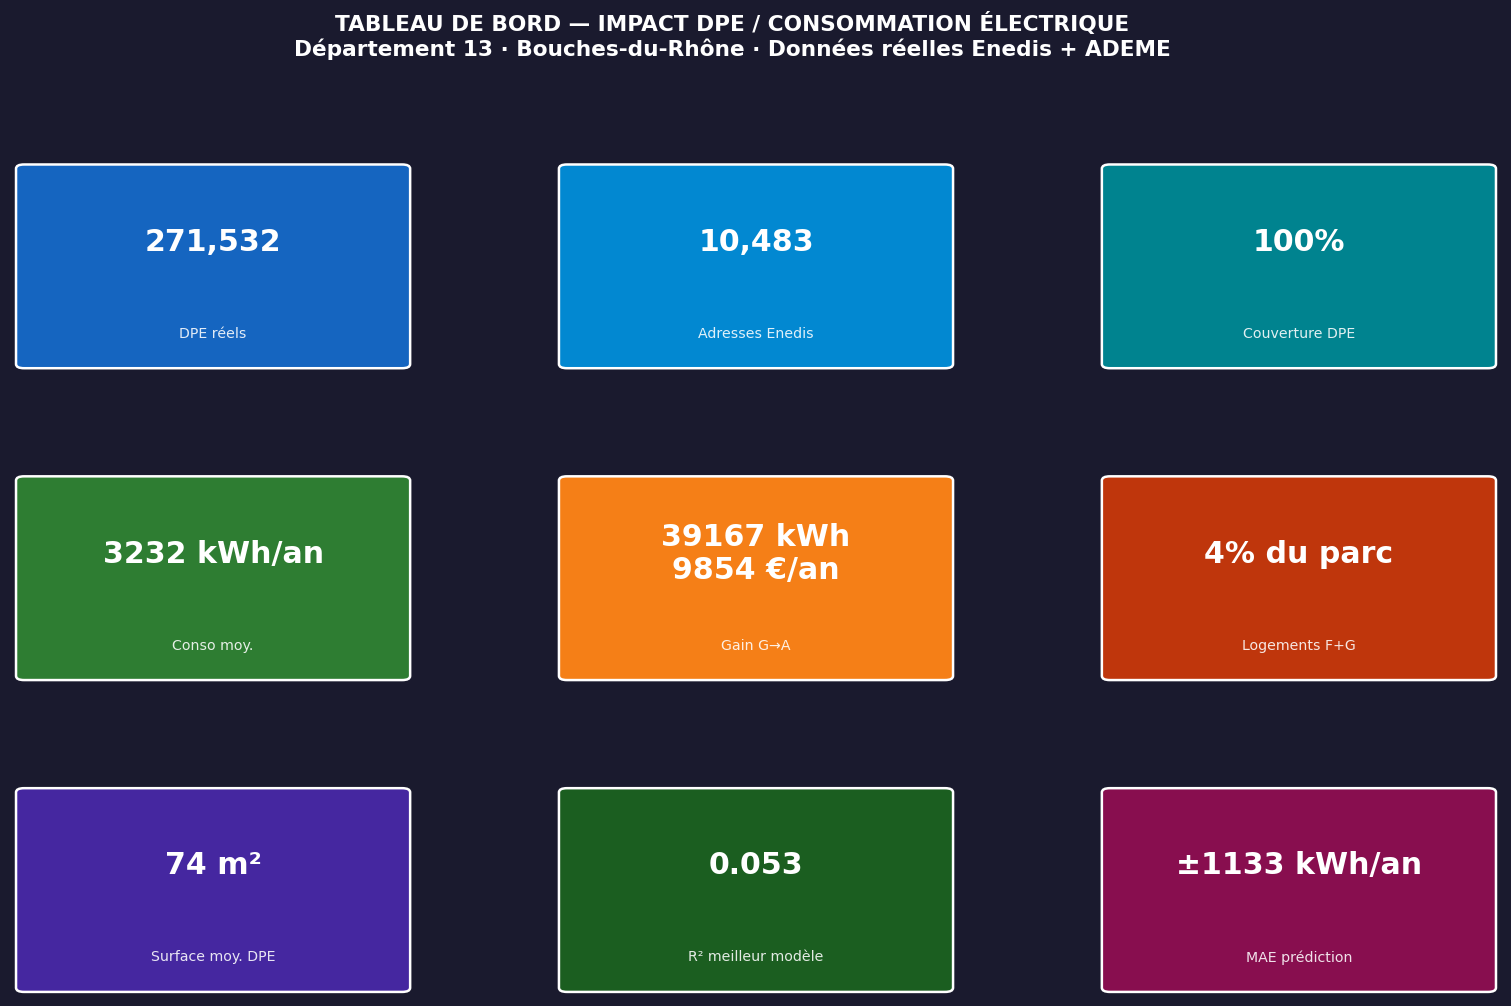


✅ KPIs sauvegardés dans outputs/kpis.json


In [40]:
kpi = {
    "nb_dpe_reels":          int(len(dpe)),
    "nb_adresses_enedis":    int(len(df)),
    "couverture_pct":        round(pct_couv, 1),
    "conso_moy_kwh":         round(float(df["conso_moy_kwh"].mean()), 1),
    "conso_med_kwh":         round(float(df["conso_moy_kwh"].median()), 1),
    "surface_moy_m2":        round(float(dpe["surface_m2"].mean()), 1),
    "gain_G_A_kwh":          round(float(g_GA_kwh), 0),
    "gain_G_A_eur":          round(float(g_GA_eur), 0),
    "pct_FG":                round(float(pct_FG), 1),
    "meilleur_modele":       best_name,
    "r2":                    round(float(best["R2"]), 4),
    "mae_kwh":               round(float(best["MAE"]), 0),
    "dpe_importance_rf_pct": round(float(fi_rf.get("Score DPE", 0))*100, 1),
}
os.makedirs("outputs", exist_ok=True)
with open("outputs/kpis.json", "w") as f:
    json.dump(kpi, f, indent=2, ensure_ascii=False)

fig = plt.figure(figsize=(16, 9))
fig.patch.set_facecolor("#1a1a2e")
gs  = GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)

cards = [
    ("DPE réels",          f"{kpi['nb_dpe_reels']:,}",              "#1565C0"),
    ("Adresses Enedis",    f"{kpi['nb_adresses_enedis']:,}",         "#0288D1"),
    ("Couverture DPE",     f"{kpi['couverture_pct']:.0f}%",              "#00838F"),
    ("Conso moy.",         f"{kpi['conso_moy_kwh']:.0f} kWh/an",         "#2E7D32"),
    ("Gain G→A",           f"{kpi['gain_G_A_kwh']:.0f} kWh\n{kpi['gain_G_A_eur']:.0f} €/an",
                                                                     "#F57F17"),
    ("Logements F+G",      f"{kpi['pct_FG']:.0f}% du parc",          "#BF360C"),
    ("Surface moy. DPE",   f"{kpi['surface_moy_m2']:.0f} m²",        "#4527A0"),
    ("R² meilleur modèle", f"{kpi['r2']:.3f}",                        "#1B5E20"),
    ("MAE prédiction",     f"±{kpi['mae_kwh']:.0f} kWh/an",           "#880E4F"),
]
for (r, c), (lbl, val, color) in zip(
    [(i//3, i%3) for i in range(9)], cards
):
    ax = fig.add_subplot(gs[r, c])
    ax.axis("off")
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.03, 0.03), 0.94, 0.94,
        boxstyle="round,pad=0.02", facecolor=color,
        edgecolor="white", lw=1.5, transform=ax.transAxes
    ))
    ax.text(0.5, 0.62, val, ha="center", va="center",
            fontsize=18, fontweight="bold", color="white",
            transform=ax.transAxes)
    ax.text(0.5, 0.18, lbl, ha="center", va="center",
            fontsize=8.5, color="white", alpha=0.88,
            transform=ax.transAxes)

fig.suptitle("TABLEAU DE BORD — IMPACT DPE / CONSOMMATION ÉLECTRIQUE\n"
             "Département 13 · Bouches-du-Rhône · Données réelles Enedis + ADEME",
             fontsize=13, fontweight="bold", color="white", y=1.02)
plt.savefig(f"{OUTDIR}/fig13_dashboard.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

print("\n✅ KPIs sauvegardés dans outputs/kpis.json")
